In [15]:
!pip install -q kaggle imbalanced-learn

In [16]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Set styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Setup complete!")


Setup complete!


In [18]:
# Cell 3: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:

dataset1_path = '/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/Epileptic Seizure Recognition.csv'  # <-- YAHAN APNA PATH DALEIN

# Load the CSV
df1 = pd.read_csv(dataset1_path)

print("="*60)
print("DATASET 1: UCI Epileptic Seizure Recognition")
print("="*60)
print(f"Shape: {df1.shape}")
print(f"\nFirst 5 column names: {df1.columns[:5].tolist()}")
print(f"Last 3 column names: {df1.columns[-3:].tolist()}")

print(f"\n--- First 3 rows ---")
print(df1.head(3))

print(f"\n--- Data types ---")
print(df1.dtypes.value_counts())

print(f"\n--- Missing values ---")
print(f"Total missing: {df1.isnull().sum().sum()}")

DATASET 1: UCI Epileptic Seizure Recognition
Shape: (11500, 180)

First 5 column names: ['Unnamed', 'X1', 'X2', 'X3', 'X4']
Last 3 column names: ['X177', 'X178', 'y']

--- First 3 rows ---
      Unnamed   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X170  X171  \
0  X21.V1.791  135  190  229  223  192  125   55   -9  -33  ...   -17   -15   
1  X15.V1.924  386  382  356  331  320  315  307  272  244  ...   164   150   
2     X8.V1.1  -32  -39  -47  -37  -32  -36  -57  -73  -85  ...    57    64   

   X172  X173  X174  X175  X176  X177  X178  y  
0   -31   -77  -103  -127  -116   -83   -51  4  
1   146   152   157   156   154   143   129  1  
2    48    19   -12   -30   -35   -35   -36  5  

[3 rows x 180 columns]

--- Data types ---
int64     179
object      1
Name: count, dtype: int64

--- Missing values ---
Total missing: 0


Original 5-class distribution:
y
1    2300
2    2300
3    2300
4    2300
5    2300
Name: count, dtype: int64

Class meanings:
  1 = Seizure activity (EPILEPTIC)
  2 = Tumor area EEG (non-seizure)
  3 = Healthy area EEG (non-seizure)
  4 = Eyes closed (non-seizure)
  5 = Eyes open (non-seizure)

Binary class distribution:
y_binary
0    9200
1    2300
Name: count, dtype: int64
Seizure ratio: 20.00%
Non-seizure ratio: 80.00%


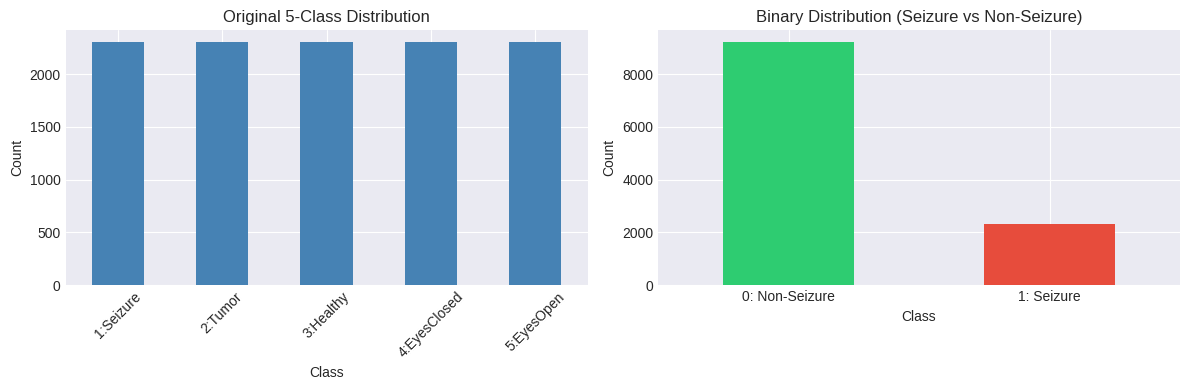

In [20]:
# Cell 5: Explore class distribution and convert to binary

# Original classes (1-5)
print("Original 5-class distribution:")
print(df1['y'].value_counts().sort_index())
print("\nClass meanings:")
print("  1 = Seizure activity (EPILEPTIC)")
print("  2 = Tumor area EEG (non-seizure)")
print("  3 = Healthy area EEG (non-seizure)")
print("  4 = Eyes closed (non-seizure)")
print("  5 = Eyes open (non-seizure)")

# Binary conversion: 1 = seizure, 0 = non-seizure
df1['y_binary'] = (df1['y'] == 1).astype(int)

print(f"\n{'='*40}")
print("Binary class distribution:")
print(df1['y_binary'].value_counts())
print(f"Seizure ratio: {df1['y_binary'].mean()*100:.2f}%")
print(f"Non-seizure ratio: {(1-df1['y_binary'].mean())*100:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Original 5 classes
df1['y'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Original 5-Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['1:Seizure', '2:Tumor', '3:Healthy', '4:EyesClosed', '5:EyesOpen'], rotation=45)

# Plot 2: Binary
df1['y_binary'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Binary Distribution (Seizure vs Non-Seizure)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['0: Non-Seizure', '1: Seizure'], rotation=0)

plt.tight_layout()
plt.savefig('dataset1_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

Number of features: 178


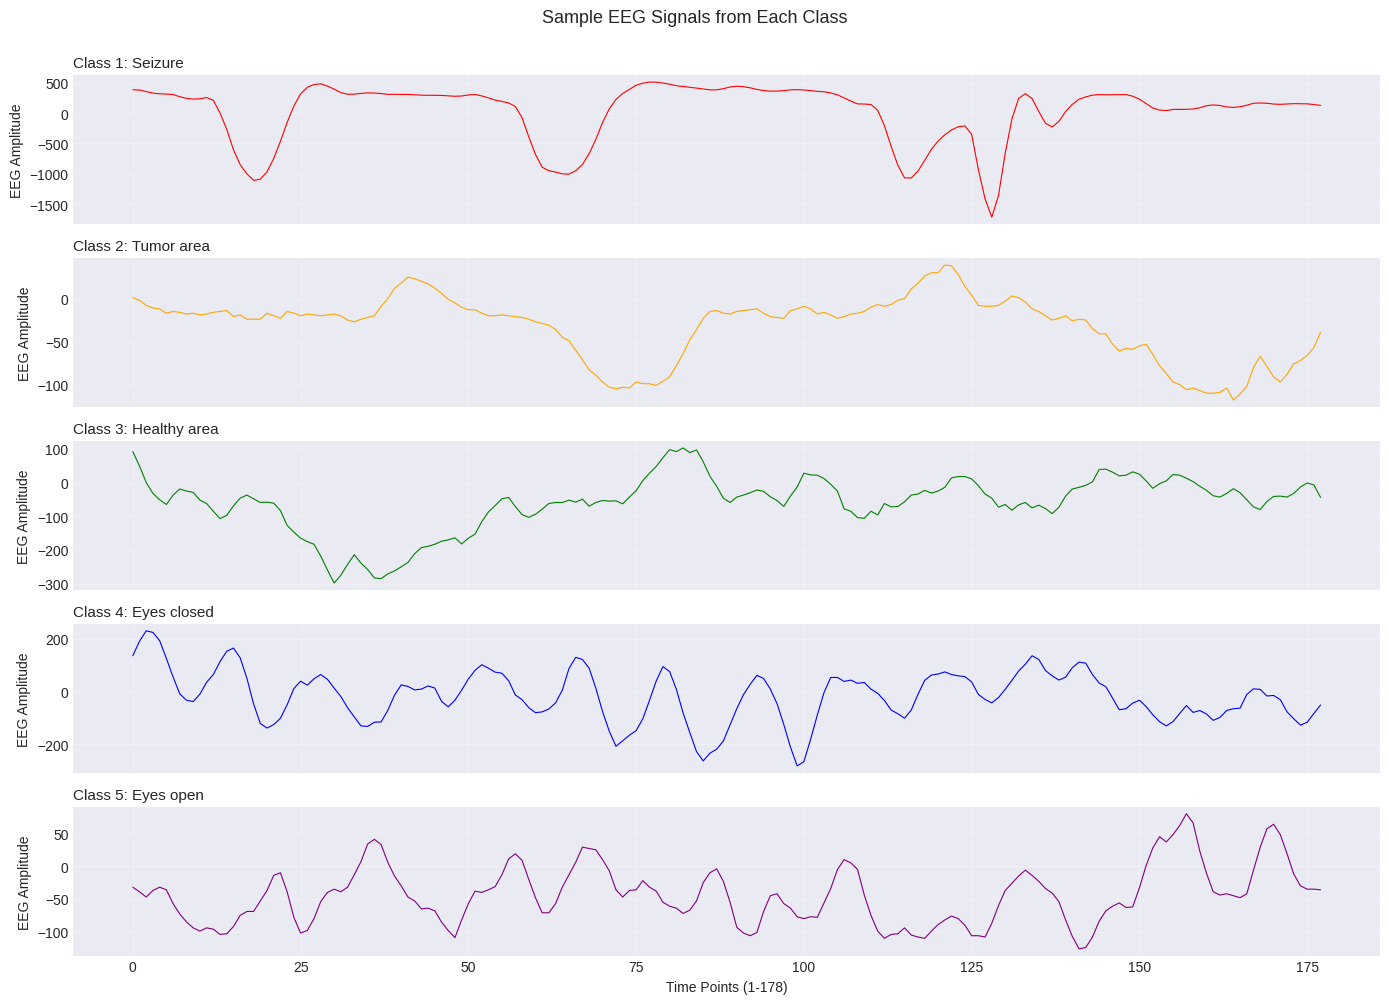


Notice: Class 1 (Seizure) signals dikh rahe hain - high amplitude, irregular pattern
Yeh visual difference hi machine learning model dhundh ke classify karta hai


In [21]:
# Cell 6: Plot sample EEG signals from each class

# Get feature columns (X1 to X178 are the EEG values)
feature_cols = [col for col in df1.columns if col.startswith('X')]
print(f"Number of features: {len(feature_cols)}")

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
class_names = {1: 'Seizure', 2: 'Tumor area', 3: 'Healthy area',
               4: 'Eyes closed', 5: 'Eyes open'}
colors = ['red', 'orange', 'green', 'blue', 'purple']

for i, (cls, name) in enumerate(class_names.items()):
    # Get one sample from each class
    sample = df1[df1['y'] == cls].iloc[0][feature_cols].values
    axes[i].plot(sample, color=colors[i], linewidth=0.8)
    axes[i].set_title(f'Class {cls}: {name}', fontsize=11, loc='left')
    axes[i].set_ylabel('EEG Amplitude')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('Time Points (1-178)')
plt.suptitle('Sample EEG Signals from Each Class', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('dataset1_eeg_samples.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nNotice: Class 1 (Seizure) signals dikh rahe hain - high amplitude, irregular pattern")
print("Yeh visual difference hi machine learning model dhundh ke classify karta hai")

In [22]:
# Cell 7: Final summary of Dataset 1
print("="*60)
print("DATASET 1 - FINAL SUMMARY")
print("="*60)

# Save features and labels for later use
X1 = df1[feature_cols].values  # All 178 features
y1 = df1['y_binary'].values    # Binary labels

print(f"X1 shape (features): {X1.shape}")
print(f"y1 shape (labels): {y1.shape}")
print(f"Number of seizure samples: {y1.sum()}")
print(f"Number of non-seizure samples: {(y1==0).sum()}")
print(f"Imbalance ratio: 1:{(y1==0).sum() // y1.sum()}")

# Basic stats
print(f"\nFeature statistics:")
print(f"  Min value across all features: {X1.min():.2f}")
print(f"  Max value across all features: {X1.max():.2f}")
print(f"  Mean: {X1.mean():.2f}")
print(f"  Std: {X1.std():.2f}")

# Define save_path and save X1, y1 for later use
save_path = '/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/'
import numpy as np # Ensure numpy is imported for np.save
np.save(save_path + 'X1.npy', X1)
np.save(save_path + 'y1.npy', y1)

print("\n✅ Dataset 1 ready!")
print("✅ X1 and y1 saved to .npy files.")

DATASET 1 - FINAL SUMMARY
X1 shape (features): (11500, 178)
y1 shape (labels): (11500,)
Number of seizure samples: 2300
Number of non-seizure samples: 9200
Imbalance ratio: 1:4

Feature statistics:
  Min value across all features: -1885.00
  Max value across all features: 2047.00
  Mean: -7.72
  Std: 164.59

✅ Dataset 1 ready!
✅ X1 and y1 saved to .npy files.


In [23]:
# Cell 8: Explore Dataset 2 and 3 folders structure

print("="*60)
print("DATASET 2 (Bonn University) - Folder Contents:")
print("="*60)
!ls -la "/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/Bonn Univeristy Dataset"

print("\n" + "="*60)
print("DATASET 3 (CHB-MIT) - Folder Contents:")
print("="*60)
!ls -la "/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/chbmit"

DATASET 2 (Bonn University) - Folder Contents:
total 20
drwx------ 2 root root 4096 Apr 28 16:13 F
drwx------ 2 root root 4096 Apr 28 16:13 N
drwx------ 2 root root 4096 Apr 28 16:13 O
drwx------ 2 root root 4096 Apr 28 16:13 S
drwx------ 2 root root 4096 Apr 28 16:13 Z

DATASET 3 (CHB-MIT) - Folder Contents:
total 3117202
-rw------- 1 root root  390182120 Apr 28 16:25 eeg-predictive_train.npz
-rw------- 1 root root   30906000 Apr 28 16:25 eeg-predictive_val_balanced.npz
-rw------- 1 root root   68878272 Apr 28 16:25 eeg-predictive_val.npz
-rw------- 1 root root  380223766 Apr 28 16:25 eeg-seizure_test.npz
-rw------- 1 root root 1774521128 Apr 28 16:25 eeg-seizure_train.npz
-rw------- 1 root root  167059680 Apr 28 16:25 eeg-seizure_val_balanced.npz
-rw------- 1 root root  380241480 Apr 28 16:25 eeg-seizure_val.npz


In [24]:
# Cell 9: Check Bonn dataset - one folder ke files dekho
bonn_path = "/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/Bonn Univeristy Dataset"

print("Files in folder Z (Healthy, eyes open):")
!ls "{bonn_path}/Z" | head -10
print("\nTotal files in Z:")
!ls "{bonn_path}/Z" | wc -l

print("\nFiles in folder S (Seizure):")
!ls "{bonn_path}/S" | head -10
print("\nTotal files in S:")
!ls "{bonn_path}/S" | wc -l

# Ek sample file ka content dekhein
print("\n--- Sample file content (first 10 lines of Z/Z001.txt) ---")
import os
sample_file = os.path.join(bonn_path, 'Z', sorted(os.listdir(os.path.join(bonn_path, 'Z')))[0])
print(f"Sample file: {sample_file}")
!head -10 "{sample_file}"
print(f"\nTotal lines in sample file:")
!wc -l "{sample_file}"

Files in folder Z (Healthy, eyes open):
Z001.txt
Z002.txt
Z003.txt
Z004.txt
Z005.txt
Z006.txt
Z007.txt
Z008.txt
Z009.txt
Z010.txt

Total files in Z:
100

Files in folder S (Seizure):
S001.txt
S002.txt
S003.txt
S004.txt
S005.txt
S006.txt
S007.txt
S008.txt
S009.txt
S010.txt

Total files in S:
100

--- Sample file content (first 10 lines of Z/Z001.txt) ---
Sample file: /content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/Bonn Univeristy Dataset/Z/Z001.txt
12
22
35
45
69
74
79
78
66
43

Total lines in sample file:
4097 /content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/Bonn Univeristy Dataset/Z/Z001.txt


In [25]:
import numpy as np

# Cell 10: Check CHB-MIT npz files structure
chbmit_path = "/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/chbmit"

# Smallest file load karke structure dekhein (val_balanced - chhoti file hai)
print("Loading CHB-MIT validation balanced file (smallest)...")
data = np.load(f"{chbmit_path}/eeg-seizure_val_balanced.npz")

print("\nKeys in npz file:")
print(list(data.keys()))

for key in data.keys():
    arr = data[key]
    print(f"\n  '{key}':")
    print(f"     Shape: {arr.shape}")
    print(f"     Dtype: {arr.dtype}")
    if arr.ndim <= 2 and arr.size < 100:
        print(f"     Values: {arr}")
    else:
        print(f"     Min: {arr.min():.3f}, Max: {arr.max():.3f}, Mean: {arr.mean():.3f}")

# Agar 'y' ya 'labels' key hai to class distribution check karein
for label_key in ['y', 'labels', 'label', 'targets']:
    if label_key in data.keys():
        labels = data[label_key]
        print(f"\n--- Class distribution in '{label_key}' ---")
        unique, counts = np.unique(labels, return_counts=True)
        for u, c in zip(unique, counts):
            print(f"  Class {u}: {c} samples ({c/len(labels)*100:.2f}%)")
        break

Loading CHB-MIT validation balanced file (smallest)...

Keys in npz file:
['val_signals', 'val_labels']

  'val_signals':
     Shape: (3546, 23, 256)
     Dtype: float64
     Min: -2328.107, Max: 2429.011, Mean: 0.156

  'val_labels':
     Shape: (3546,)
     Dtype: int64
     Min: 0.000, Max: 1.000, Mean: 0.500


In [26]:
# Cell 11: Load full Bonn dataset
import os
import numpy as np
from glob import glob

bonn_path = "/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/Bonn Univeristy Dataset"

# Class mapping:
# Z, O = Healthy (label 0)
# N, F = Interictal/Non-seizure epileptic patients (label 0)
# S    = Seizure activity (label 1)

# Standard binary classification: Seizure (S) vs Non-Seizure (Z, O, N, F)
folder_labels = {'Z': 0, 'O': 0, 'N': 0, 'F': 0, 'S': 1}

X2_list = []
y2_list = []

for folder, label in folder_labels.items():
    folder_path = os.path.join(bonn_path, folder)
    files = sorted(glob(os.path.join(folder_path, '*.txt')))
    print(f"Folder {folder}: {len(files)} files (label = {label})")

    for file in files:
        # Read EEG values from txt file
        signal = np.loadtxt(file)
        X2_list.append(signal)
        y2_list.append(label)

# Convert to numpy arrays
X2 = np.array(X2_list)
y2 = np.array(y2_list)

print(f"\n{'='*50}")
print(f"DATASET 2 (Bonn) - Loaded Successfully!")
print(f"{'='*50}")
print(f"X2 shape: {X2.shape}")
print(f"y2 shape: {y2.shape}")
print(f"Seizure samples: {y2.sum()} ({y2.mean()*100:.1f}%)")
print(f"Non-seizure samples: {(y2==0).sum()} ({(1-y2.mean())*100:.1f}%)")
print(f"Imbalance ratio: 1:{(y2==0).sum() // y2.sum()}")
print(f"Feature range: [{X2.min():.1f}, {X2.max():.1f}]")

Folder Z: 100 files (label = 0)
Folder O: 100 files (label = 0)
Folder N: 0 files (label = 0)
Folder F: 100 files (label = 0)
Folder S: 100 files (label = 1)

DATASET 2 (Bonn) - Loaded Successfully!
X2 shape: (400, 4097)
y2 shape: (400,)
Seizure samples: 100 (25.0%)
Non-seizure samples: 300 (75.0%)
Imbalance ratio: 1:3
Feature range: [-1885.0, 2047.0]


Skipping folder N as no files were found for visualization.


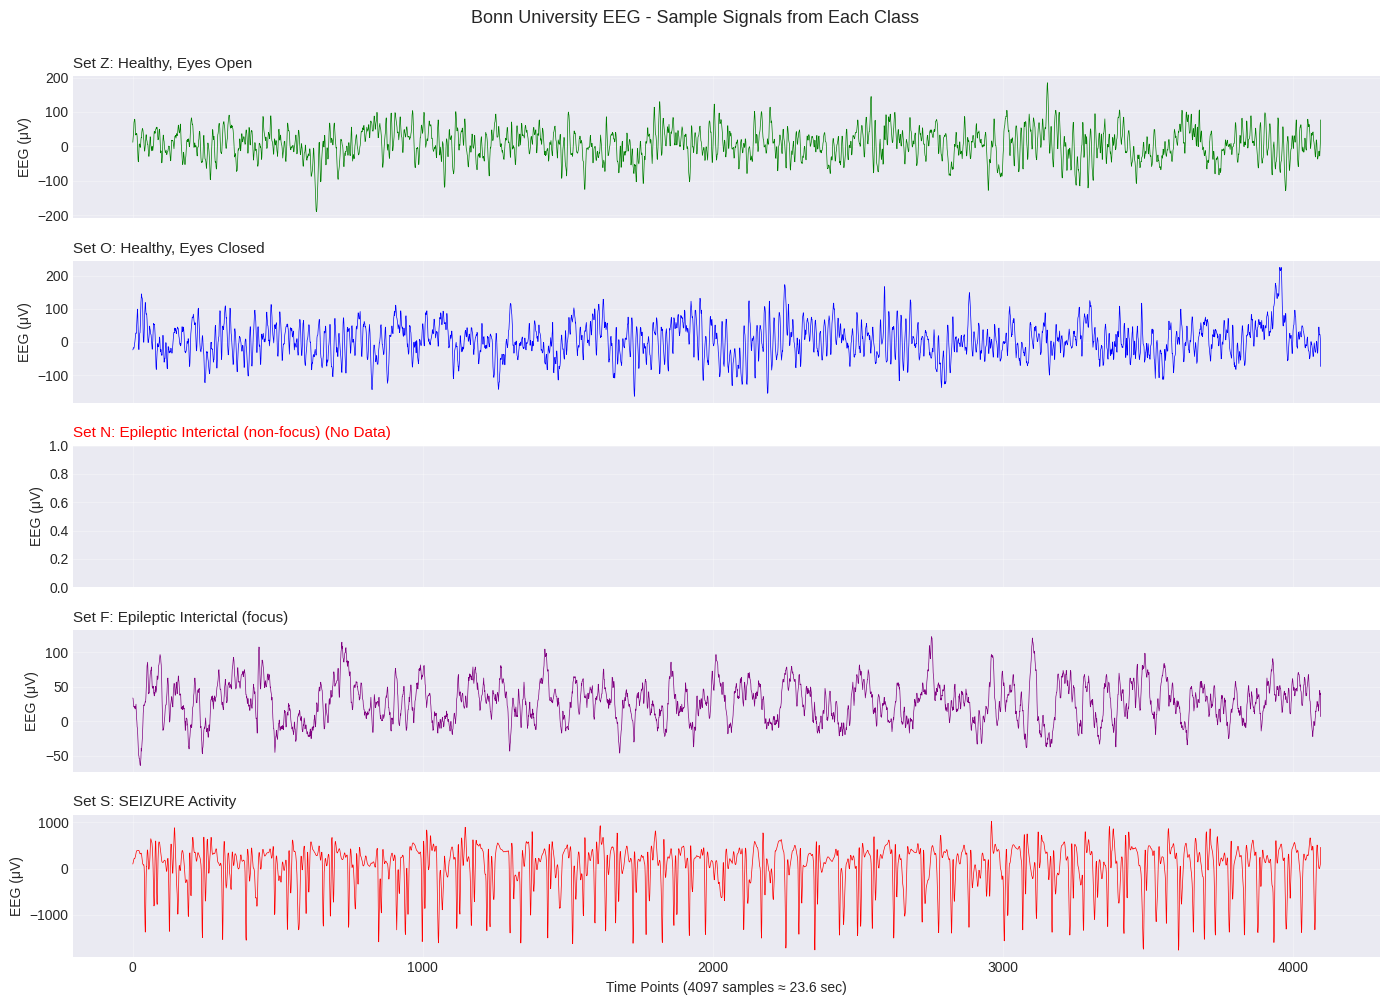

Notice: Set S (Seizure) signals - bohot zyada amplitude aur irregular pattern dikh raha hai


In [27]:
# Cell 12: Visualize Bonn dataset signals
import matplotlib.pyplot as plt
import os
from glob import glob
import numpy as np

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
folder_names_full = {
    'Z': 'Healthy, Eyes Open',
    'O': 'Healthy, Eyes Closed',
    'N': 'Epileptic Interictal (non-focus)',
    'F': 'Epileptic Interictal (focus)',
    'S': 'SEIZURE Activity'
}
colors = ['green', 'blue', 'orange', 'purple', 'red']

# Pehle har folder se ek sample lein
for i, (folder, name) in enumerate(folder_names_full.items()):
    files_in_folder = sorted(glob(os.path.join(bonn_path, folder, '*.txt')))
    if not files_in_folder:
        print(f"Skipping folder {folder} as no files were found for visualization.")
        axes[i].set_title(f'Set {folder}: {name} (No Data)', fontsize=11, loc='left', color='red')
        axes[i].set_ylabel('EEG (μV)')
        axes[i].grid(alpha=0.3)
        continue
    sample_file = files_in_folder[0]
    signal = np.loadtxt(sample_file)
    axes[i].plot(signal, color=colors[i], linewidth=0.5)
    axes[i].set_title(f'Set {folder}: {name}', fontsize=11, loc='left')
    axes[i].set_ylabel('EEG (μV)')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('Time Points (4097 samples ≈ 23.6 sec)')
plt.suptitle('Bonn University EEG - Sample Signals from Each Class', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('dataset2_bonn_samples.png', dpi=100, bbox_inches='tight')
plt.show()

print("Notice: Set S (Seizure) signals - bohot zyada amplitude aur irregular pattern dikh raha hai")


In [28]:
# Cell 13: Load CHB-MIT dataset (val_balanced - already balanced, manageable size)
chbmit_path = "/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/chbmit"

print("Loading CHB-MIT seizure detection (balanced validation set)...")
data = np.load(f"{chbmit_path}/eeg-seizure_val_balanced.npz")

X3_raw = data['val_signals']   # Shape: (3546, 23, 256)
y3 = data['val_labels']         # Shape: (3546,)

print(f"Raw shape: {X3_raw.shape}")
print(f"  - 3546 samples")
print(f"  - 23 EEG channels")
print(f"  - 256 timepoints per channel")

# Flatten for logistic regression: (3546, 23*256) = (3546, 5888)
X3 = X3_raw.reshape(X3_raw.shape[0], -1)

print(f"\nFlattened shape: {X3.shape}")
print(f"y3 shape: {y3.shape}")
print(f"Seizure samples: {y3.sum()} ({y3.mean()*100:.1f}%)")
print(f"Non-seizure samples: {(y3==0).sum()} ({(1-y3.mean())*100:.1f}%)")
print(f"Feature range: [{X3.min():.1f}, {X3.max():.1f}]")

# IMPORTANT: Yeh balanced version hai - assignment ke liye hum
# imbalanced version bhi use karenge (predictive_val) for SMOTE study

Loading CHB-MIT seizure detection (balanced validation set)...
Raw shape: (3546, 23, 256)
  - 3546 samples
  - 23 EEG channels
  - 256 timepoints per channel

Flattened shape: (3546, 5888)
y3 shape: (3546,)
Seizure samples: 1773 (50.0%)
Non-seizure samples: 1773 (50.0%)
Feature range: [-2328.1, 2429.0]


In [29]:
# Cell 14: Load imbalanced version of CHB-MIT for class imbalance study
print("Loading CHB-MIT predictive (imbalanced) for SMOTE/class weighting study...")
data_imb = np.load(f"{chbmit_path}/eeg-predictive_val.npz")

print("Keys:", list(data_imb.keys()))

# Same structure - val_signals, val_labels
X3_imb_raw = data_imb['val_signals']
y3_imb = data_imb['val_labels']

X3_imb = X3_imb_raw.reshape(X3_imb_raw.shape[0], -1)

print(f"\nImbalanced version shape: {X3_imb.shape}")
print(f"Seizure (preictal) samples: {y3_imb.sum()} ({y3_imb.mean()*100:.2f}%)")
print(f"Non-seizure samples: {(y3_imb==0).sum()} ({(1-y3_imb.mean())*100:.2f}%)")
print(f"Imbalance ratio: 1:{(y3_imb==0).sum() // max(y3_imb.sum(),1)}")

Loading CHB-MIT predictive (imbalanced) for SMOTE/class weighting study...
Keys: ['val_signals', 'val_labels']

Imbalanced version shape: (1462, 5888)
Seizure (preictal) samples: 328.0 (22.44%)
Non-seizure samples: 1134 (77.56%)
Imbalance ratio: 1:3.0


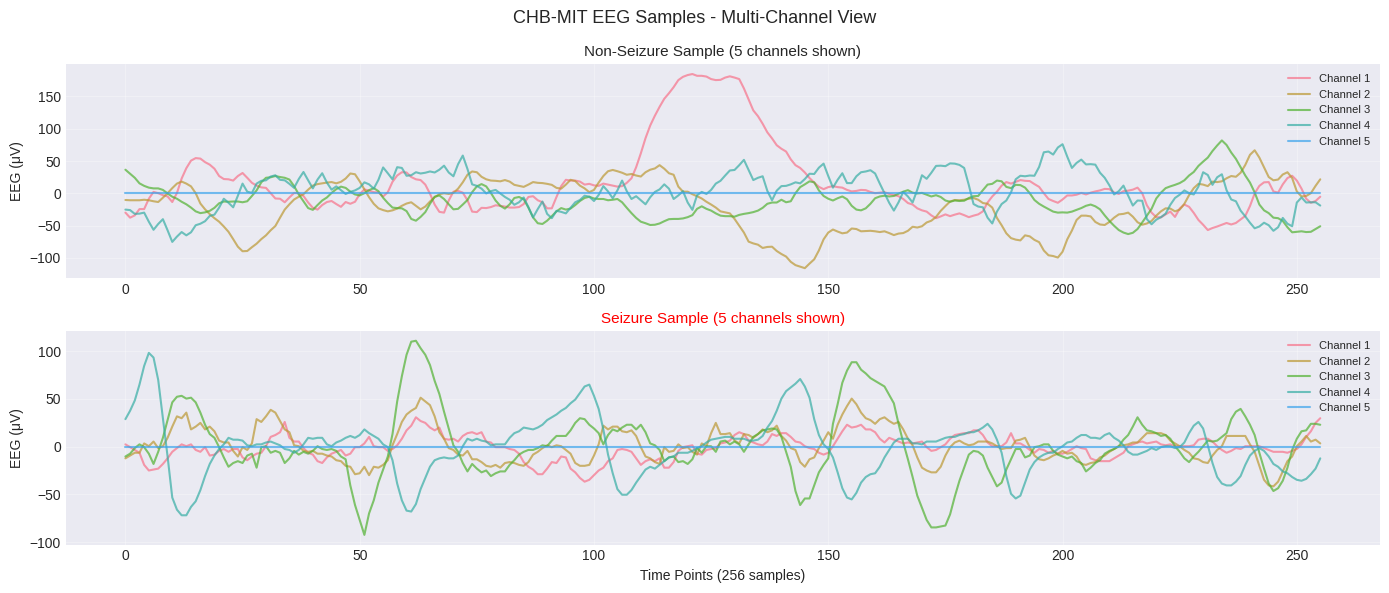

In [30]:
# Cell 15: Visualize CHB-MIT signals
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Non-seizure sample
non_seizure_idx = np.where(y3 == 0)[0][0]
seizure_idx = np.where(y3 == 1)[0][0]

# Plot first 5 channels of non-seizure sample
for ch in range(5):
    axes[0].plot(X3_raw[non_seizure_idx, ch, :],
                 label=f'Channel {ch+1}', alpha=0.7)
axes[0].set_title('Non-Seizure Sample (5 channels shown)', fontsize=11)
axes[0].set_ylabel('EEG (μV)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(alpha=0.3)

# Plot first 5 channels of seizure sample
for ch in range(5):
    axes[1].plot(X3_raw[seizure_idx, ch, :],
                 label=f'Channel {ch+1}', alpha=0.7)
axes[1].set_title('Seizure Sample (5 channels shown)', fontsize=11, color='red')
axes[1].set_ylabel('EEG (μV)')
axes[1].set_xlabel('Time Points (256 samples)')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('CHB-MIT EEG Samples - Multi-Channel View', fontsize=13)
plt.tight_layout()
plt.savefig('dataset3_chbmit_samples.png', dpi=100, bbox_inches='tight')
plt.show()

In [32]:
# Cell 16: Step 1 Complete - Summary of all 3 datasets

print("="*70)
print("STEP 1 COMPLETE: ALL 3 DATASETS LOADED")
print("="*70)

datasets = {
    'Dataset 1 (UCI Epileptic)': (X1, y1, 'Pre-extracted features'),
    'Dataset 2 (Bonn University)': (X2, y2, 'Raw time-series (single channel)'),
    'Dataset 3 (CHB-MIT balanced)': (X3, y3, 'Raw multi-channel time-series'),
    'Dataset 3b (CHB-MIT imbalanced)': (X3_imb, y3_imb, 'For imbalance study')
}

summary_data = []
for name, (X, y, ftype) in datasets.items():
    summary_data.append({
        'Dataset': name,
        'Samples': X.shape[0],
        'Features': X.shape[1],
        'Seizure %': f"{y.mean()*100:.1f}%",
        'Imbalance': f"1:{(y==0).sum() // max(y.sum(),1)}",
        'Type': ftype
    })

import pandas as pd
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save all datasets to Drive for next steps
save_path = '/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/'
np.save(save_path + 'X2.npy', X2)
np.save(save_path + 'y2.npy', y2)
np.save(save_path + 'X3.npy', X3)
np.save(save_path + 'y3.npy', y3)
np.save(save_path + 'X3_imb.npy', X3_imb)
np.save(save_path + 'y3_imb.npy', y3_imb)

print("\n✅ All datasets saved as .npy files for fast loading later")
print("✅ Step 1: Dataset Collection - COMPLETE!")
print("\n→ Next: Step 2 - Preprocessing Pipelines (CRITICAL PART)")

STEP 1 COMPLETE: ALL 3 DATASETS LOADED
                        Dataset  Samples  Features Seizure % Imbalance                             Type
      Dataset 1 (UCI Epileptic)    11500       178     20.0%       1:4           Pre-extracted features
    Dataset 2 (Bonn University)      400      4097     25.0%       1:3 Raw time-series (single channel)
   Dataset 3 (CHB-MIT balanced)     3546      5888     50.0%       1:1    Raw multi-channel time-series
Dataset 3b (CHB-MIT imbalanced)     1462      5888     22.4%     1:3.0              For imbalance study

✅ All datasets saved as .npy files for fast loading later
✅ Step 1: Dataset Collection - COMPLETE!

→ Next: Step 2 - Preprocessing Pipelines (CRITICAL PART)


**Step 2: Preprocessing Pipelines**  
ordering of preprocessing steps affects performance

In [33]:
# Cell 17: Imports for preprocessing pipelines
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy import signal as sp_signal
from scipy.stats import skew, kurtosis
import time

# Reload datasets if needed (incase runtime restart)
save_path = '/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/'
X1 = np.load(save_path + 'X1.npy'); y1 = np.load(save_path + 'y1.npy')
X2 = np.load(save_path + 'X2.npy'); y2 = np.load(save_path + 'y2.npy')
X3 = np.load(save_path + 'X3.npy'); y3 = np.load(save_path + 'y3.npy')
X3_imb = np.load(save_path + 'X3_imb.npy'); y3_imb = np.load(save_path + 'y3_imb.npy')

print("✅ All datasets loaded")
print(f"X1: {X1.shape}, X2: {X2.shape}, X3: {X3.shape}, X3_imb: {X3_imb.shape}")

✅ All datasets loaded
X1: (11500, 178), X2: (400, 4097), X3: (3546, 5888), X3_imb: (1462, 5888)


In [34]:
# Cell 18: Pipeline A components
# Order: Normalization → Noise Removal → Feature Selection

def pipeline_A(X_train, X_test, y_train, k_features=50, lowcut=0.5, highcut=40, fs=173.6):
    """
    Pipeline A: Normalization → Noise Removal → Feature Selection

    Step 1: Z-score normalization (mean=0, std=1)
    Step 2: Bandpass filter (remove noise outside 0.5-40 Hz)
    Step 3: Select top-k features using ANOVA F-test

    Args:
        X_train, X_test: feature matrices
        y_train: training labels (needed for feature selection)
        k_features: how many top features to keep
        lowcut, highcut: bandpass filter cutoffs (Hz)
        fs: sampling frequency
    """
    print(f"\n{'─'*50}")
    print(f"PIPELINE A: Normalize → Denoise → Feature Select")
    print(f"{'─'*50}")
    print(f"Input shape: Train {X_train.shape}, Test {X_test.shape}")

    # ===== STEP 1: Normalization =====
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)
    print(f"  ✓ Step 1 - Normalized: mean={X_train_norm.mean():.3f}, std={X_train_norm.std():.3f}")

    # ===== STEP 2: Noise Removal (Bandpass Filter) =====
    # Apply bandpass filter to remove noise outside EEG frequency range
    # EEG meaningful frequencies: 0.5-40 Hz (delta, theta, alpha, beta, gamma)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = min(highcut / nyq, 0.99)  # Ensure < 1

    # Adjust filter order based on signal length
    filter_order = min(4, X_train_norm.shape[1] // 4)

    try:
        b, a = sp_signal.butter(filter_order, [low, high], btype='band')
        X_train_clean = np.array([sp_signal.filtfilt(b, a, row) for row in X_train_norm])
        X_test_clean = np.array([sp_signal.filtfilt(b, a, row) for row in X_test_norm])
        print(f"  ✓ Step 2 - Bandpass filtered: [{lowcut}-{highcut}] Hz")
    except Exception as e:
        print(f"  ⚠ Filter failed ({e}), skipping noise removal")
        X_train_clean = X_train_norm
        X_test_clean = X_test_norm

    # ===== STEP 3: Feature Selection =====
    k = min(k_features, X_train_clean.shape[1])
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_final = selector.fit_transform(X_train_clean, y_train)
    X_test_final = selector.transform(X_test_clean)
    print(f"  ✓ Step 3 - Feature selection: {X_train_clean.shape[1]} → {k} features")

    print(f"Output shape: Train {X_train_final.shape}, Test {X_test_final.shape}")

    return X_train_final, X_test_final


# Test on Dataset 1
print("Testing Pipeline A on Dataset 1...")
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

X1_train_A, X1_test_A = pipeline_A(X1_train, X1_test, y1_train, k_features=50)

Testing Pipeline A on Dataset 1...

──────────────────────────────────────────────────
PIPELINE A: Normalize → Denoise → Feature Select
──────────────────────────────────────────────────
Input shape: Train (9200, 178), Test (2300, 178)
  ✓ Step 1 - Normalized: mean=0.000, std=1.000
  ✓ Step 2 - Bandpass filtered: [0.5-40] Hz
  ✓ Step 3 - Feature selection: 178 → 50 features
Output shape: Train (9200, 50), Test (2300, 50)


In [35]:
# Cell 19: Pipeline B components
# Order: Feature Extraction → Scaling → PCA

def extract_statistical_features(X):
    """
    Extract statistical features from each row (signal):
    Time-domain: mean, std, max, min, skewness, kurtosis, RMS, etc.
    Frequency-domain: power in different bands
    """
    features = []

    for row in X:
        feat = []
        # Time-domain features
        feat.append(np.mean(row))                          # Mean
        feat.append(np.std(row))                           # Std deviation
        feat.append(np.max(row))                           # Max
        feat.append(np.min(row))                           # Min
        feat.append(np.max(row) - np.min(row))             # Range
        feat.append(np.median(row))                        # Median
        feat.append(skew(row))                             # Skewness
        feat.append(kurtosis(row))                         # Kurtosis
        feat.append(np.sqrt(np.mean(row**2)))              # RMS
        feat.append(np.sum(np.abs(np.diff(row))))          # Line length
        feat.append(np.mean(np.abs(row)))                  # Mean abs
        feat.append(np.percentile(row, 25))                # Q1
        feat.append(np.percentile(row, 75))                # Q3
        feat.append(np.var(row))                           # Variance

        # Frequency-domain features (FFT-based)
        fft_vals = np.abs(np.fft.rfft(row))
        if len(fft_vals) > 0:
            feat.append(np.mean(fft_vals))                 # FFT mean
            feat.append(np.std(fft_vals))                  # FFT std
            feat.append(np.max(fft_vals))                  # FFT max
            feat.append(np.argmax(fft_vals))               # Dominant freq idx

            # Power in bands (split FFT into 5 bands)
            n_bands = 5
            band_size = len(fft_vals) // n_bands
            for i in range(n_bands):
                start = i * band_size
                end = (i+1) * band_size if i < n_bands-1 else len(fft_vals)
                feat.append(np.sum(fft_vals[start:end]**2))  # Band power

        features.append(feat)

    return np.array(features)


def pipeline_B(X_train, X_test, y_train, n_components=10):
    """
    Pipeline B: Feature Extraction → Scaling → PCA

    Step 1: Extract statistical/frequency features (~23 features per signal)
    Step 2: Scale extracted features
    Step 3: Apply PCA for dimensionality reduction
    """
    print(f"\n{'─'*50}")
    print(f"PIPELINE B: Feature Extract → Scale → PCA")
    print(f"{'─'*50}")
    print(f"Input shape: Train {X_train.shape}, Test {X_test.shape}")

    # ===== STEP 1: Feature Extraction =====
    X_train_feat = extract_statistical_features(X_train)
    X_test_feat = extract_statistical_features(X_test)
    print(f"  ✓ Step 1 - Features extracted: {X_train.shape[1]} → {X_train_feat.shape[1]} features")

    # Handle any NaN/Inf from feature extraction
    X_train_feat = np.nan_to_num(X_train_feat, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_feat = np.nan_to_num(X_test_feat, nan=0.0, posinf=0.0, neginf=0.0)

    # ===== STEP 2: Scaling =====
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    print(f"  ✓ Step 2 - Scaled: mean={X_train_scaled.mean():.3f}, std={X_train_scaled.std():.3f}")

    # ===== STEP 3: PCA =====
    n_comp = min(n_components, X_train_scaled.shape[1], X_train_scaled.shape[0])
    pca = PCA(n_components=n_comp)
    X_train_final = pca.fit_transform(X_train_scaled)
    X_test_final = pca.transform(X_test_scaled)
    explained_var = pca.explained_variance_ratio_.sum() * 100
    print(f"  ✓ Step 3 - PCA: {X_train_scaled.shape[1]} → {n_comp} components")
    print(f"    (Explained variance: {explained_var:.1f}%)")

    print(f"Output shape: Train {X_train_final.shape}, Test {X_test_final.shape}")

    return X_train_final, X_test_final


# Test on Dataset 1
print("Testing Pipeline B on Dataset 1...")
X1_train_B, X1_test_B = pipeline_B(X1_train, X1_test, y1_train, n_components=10)

Testing Pipeline B on Dataset 1...

──────────────────────────────────────────────────
PIPELINE B: Feature Extract → Scale → PCA
──────────────────────────────────────────────────
Input shape: Train (9200, 178), Test (2300, 178)
  ✓ Step 1 - Features extracted: 178 → 23 features
  ✓ Step 2 - Scaled: mean=0.000, std=1.000
  ✓ Step 3 - PCA: 23 → 10 components
    (Explained variance: 98.3%)
Output shape: Train (9200, 10), Test (2300, 10)


In [36]:
# Cell 20: Apply both pipelines to all datasets

# Train-test splits for all datasets
print("Creating train-test splits...")
splits = {}
for name, X, y in [('D1', X1, y1), ('D2', X2, y2), ('D3', X3, y3), ('D3_imb', X3_imb, y3_imb)]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    splits[name] = (X_tr, X_te, y_tr, y_te)
    print(f"  {name}: Train {X_tr.shape}, Test {X_te.shape}")

# Apply pipelines
print("\n" + "="*70)
print("APPLYING PIPELINE A (Normalize → Denoise → Feature Select)")
print("="*70)

pipeline_A_results = {}
for name, (X_tr, X_te, y_tr, y_te) in splits.items():
    print(f"\n>>> Dataset {name}")
    X_tr_A, X_te_A = pipeline_A(X_tr, X_te, y_tr, k_features=min(50, X_tr.shape[1]))
    pipeline_A_results[name] = (X_tr_A, X_te_A, y_tr, y_te)

print("\n" + "="*70)
print("APPLYING PIPELINE B (Feature Extract → Scale → PCA)")
print("="*70)

pipeline_B_results = {}
for name, (X_tr, X_te, y_tr, y_te) in splits.items():
    print(f"\n>>> Dataset {name}")
    X_tr_B, X_te_B = pipeline_B(X_tr, X_te, y_tr, n_components=10)
    pipeline_B_results[name] = (X_tr_B, X_te_B, y_tr, y_te)

print("\n✅ Both pipelines applied to all 4 datasets!")

Creating train-test splits...
  D1: Train (9200, 178), Test (2300, 178)
  D2: Train (320, 4097), Test (80, 4097)
  D3: Train (2836, 5888), Test (710, 5888)
  D3_imb: Train (1169, 5888), Test (293, 5888)

APPLYING PIPELINE A (Normalize → Denoise → Feature Select)

>>> Dataset D1

──────────────────────────────────────────────────
PIPELINE A: Normalize → Denoise → Feature Select
──────────────────────────────────────────────────
Input shape: Train (9200, 178), Test (2300, 178)
  ✓ Step 1 - Normalized: mean=0.000, std=1.000
  ✓ Step 2 - Bandpass filtered: [0.5-40] Hz
  ✓ Step 3 - Feature selection: 178 → 50 features
Output shape: Train (9200, 50), Test (2300, 50)

>>> Dataset D2

──────────────────────────────────────────────────
PIPELINE A: Normalize → Denoise → Feature Select
──────────────────────────────────────────────────
Input shape: Train (320, 4097), Test (80, 4097)
  ✓ Step 1 - Normalized: mean=0.000, std=1.000
  ✓ Step 2 - Bandpass filtered: [0.5-40] Hz
  ✓ Step 3 - Feature sel

In [37]:
# Cell 21: Save preprocessed data for next steps
import pickle

results_path = '/content/drive/MyDrive/DATA MINING ASSISGNMENT/Dataset/'

with open(results_path + 'pipeline_A_results.pkl', 'wb') as f:
    pickle.dump(pipeline_A_results, f)

with open(results_path + 'pipeline_B_results.pkl', 'wb') as f:
    pickle.dump(pipeline_B_results, f)

with open(results_path + 'splits.pkl', 'wb') as f:
    pickle.dump(splits, f)

print("✅ All preprocessing results saved to Drive")
print("\n📊 Summary:")
print(f"{'Dataset':<10} {'Original':<15} {'After Pipeline A':<20} {'After Pipeline B':<20}")
print("-"*65)
for name in splits.keys():
    orig = splits[name][0].shape
    pa = pipeline_A_results[name][0].shape
    pb = pipeline_B_results[name][0].shape
    print(f"{name:<10} {str(orig):<15} {str(pa):<20} {str(pb):<20}")

print("\n✅ Step 2: Preprocessing Pipelines - COMPLETE!")
print("→ Next: Step 3 - Logistic Regression Baseline")

✅ All preprocessing results saved to Drive

📊 Summary:
Dataset    Original        After Pipeline A     After Pipeline B    
-----------------------------------------------------------------
D1         (9200, 178)     (9200, 50)           (9200, 10)          
D2         (320, 4097)     (320, 50)            (320, 10)           
D3         (2836, 5888)    (2836, 50)           (2836, 10)          
D3_imb     (1169, 5888)    (1169, 50)           (1169, 10)          

✅ Step 2: Preprocessing Pipelines - COMPLETE!
→ Next: Step 3 - Logistic Regression Baseline


**🚀 Step 3: Logistic Regression Baseline**

In [38]:
# Cell 22: Setup for baseline modeling
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              average_precision_score, classification_report,
                              confusion_matrix, precision_recall_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Train model and return all key metrics.
    Returns a dictionary with metrics.
    """
    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        'Model': model_name,
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'F1': f1_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'Recall': recall_score(y_test, y_test_pred),
        'PR_AUC': average_precision_score(y_test, y_test_proba),
        'ROC_AUC': roc_auc_score(y_test, y_test_proba)
    }

    return metrics, model, y_test_pred, y_test_proba


def print_metrics(metrics):
    """Pretty print metrics."""
    print(f"  Train Accuracy : {metrics['Train_Accuracy']:.4f}")
    print(f"  Test Accuracy  : {metrics['Test_Accuracy']:.4f}")
    print(f"  F1-score       : {metrics['F1']:.4f}")
    print(f"  Precision      : {metrics['Precision']:.4f}")
    print(f"  Recall         : {metrics['Recall']:.4f}")
    print(f"  PR-AUC         : {metrics['PR_AUC']:.4f}  ⭐ (key for imbalanced)")
    print(f"  ROC-AUC        : {metrics['ROC_AUC']:.4f}")

print("✅ Evaluation helpers ready")

✅ Evaluation helpers ready


In [39]:
# Cell 23: Baseline logistic regression on Pipeline A data

print("="*70)
print("BASELINE LOGISTIC REGRESSION - PIPELINE A (Normalize→Denoise→FeatSelect)")
print("="*70)

baseline_results_A = []

for name, (X_tr, X_te, y_tr, y_te) in pipeline_A_results.items():
    print(f"\n>>> Dataset: {name}")
    print(f"    Train shape: {X_tr.shape}, Test shape: {X_te.shape}")

    # Default Logistic Regression (baseline)
    model = LogisticRegression(max_iter=1000, random_state=42)
    metrics, _, _, _ = evaluate_model(model, X_tr, X_te, y_tr, y_te,
                                       f"LR_Baseline_{name}_PipeA")
    metrics['Dataset'] = name
    metrics['Pipeline'] = 'A'
    baseline_results_A.append(metrics)

    print_metrics(metrics)

print("\n✅ Pipeline A baseline complete")

BASELINE LOGISTIC REGRESSION - PIPELINE A (Normalize→Denoise→FeatSelect)

>>> Dataset: D1
    Train shape: (9200, 50), Test shape: (2300, 50)
  Train Accuracy : 0.8154
  Test Accuracy  : 0.8100
  F1-score       : 0.0952
  Precision      : 1.0000
  Recall         : 0.0500
  PR-AUC         : 0.4701  ⭐ (key for imbalanced)
  ROC-AUC        : 0.5129

>>> Dataset: D2
    Train shape: (320, 50), Test shape: (80, 50)
  Train Accuracy : 0.9406
  Test Accuracy  : 0.8500
  F1-score       : 0.5714
  Precision      : 1.0000
  Recall         : 0.4000
  PR-AUC         : 0.6882  ⭐ (key for imbalanced)
  ROC-AUC        : 0.6133

>>> Dataset: D3
    Train shape: (2836, 50), Test shape: (710, 50)
  Train Accuracy : 0.5899
  Test Accuracy  : 0.5282
  F1-score       : 0.4517
  Precision      : 0.5391
  Recall         : 0.3887
  PR-AUC         : 0.5573  ⭐ (key for imbalanced)
  ROC-AUC        : 0.4699

>>> Dataset: D3_imb
    Train shape: (1169, 50), Test shape: (293, 50)
  Train Accuracy : 0.7887
  Test A

In [40]:
# Cell 24: Baseline logistic regression on Pipeline B data

print("="*70)
print("BASELINE LOGISTIC REGRESSION - PIPELINE B (FeatExtract→Scale→PCA)")
print("="*70)

baseline_results_B = []

for name, (X_tr, X_te, y_tr, y_te) in pipeline_B_results.items():
    print(f"\n>>> Dataset: {name}")
    print(f"    Train shape: {X_tr.shape}, Test shape: {X_te.shape}")

    model = LogisticRegression(max_iter=1000, random_state=42)
    metrics, _, _, _ = evaluate_model(model, X_tr, X_te, y_tr, y_te,
                                       f"LR_Baseline_{name}_PipeB")
    metrics['Dataset'] = name
    metrics['Pipeline'] = 'B'
    baseline_results_B.append(metrics)

    print_metrics(metrics)

print("\n✅ Pipeline B baseline complete")

BASELINE LOGISTIC REGRESSION - PIPELINE B (FeatExtract→Scale→PCA)

>>> Dataset: D1
    Train shape: (9200, 10), Test shape: (2300, 10)
  Train Accuracy : 0.9659
  Test Accuracy  : 0.9630
  F1-score       : 0.9037
  Precision      : 0.9433
  Recall         : 0.8674
  PR-AUC         : 0.9691  ⭐ (key for imbalanced)
  ROC-AUC        : 0.9885

>>> Dataset: D2
    Train shape: (320, 10), Test shape: (80, 10)
  Train Accuracy : 0.9656
  Test Accuracy  : 0.9375
  F1-score       : 0.8649
  Precision      : 0.9412
  Recall         : 0.8000
  PR-AUC         : 0.9826  ⭐ (key for imbalanced)
  ROC-AUC        : 0.9942

>>> Dataset: D3
    Train shape: (2836, 10), Test shape: (710, 10)
  Train Accuracy : 0.6738
  Test Accuracy  : 0.6620
  F1-score       : 0.6166
  Precision      : 0.7122
  Recall         : 0.5437
  PR-AUC         : 0.7571  ⭐ (key for imbalanced)
  ROC-AUC        : 0.7161

>>> Dataset: D3_imb
    Train shape: (1169, 10), Test shape: (293, 10)
  Train Accuracy : 0.7784
  Test Accuracy

In [41]:
# Cell 25: Compare baseline results across pipelines

# Combine results
all_baseline_results = baseline_results_A + baseline_results_B
results_df = pd.DataFrame(all_baseline_results)

# Reorder columns for better display
cols_order = ['Dataset', 'Pipeline', 'Train_Accuracy', 'Test_Accuracy',
              'F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']
results_df = results_df[cols_order]

print("="*90)
print("BASELINE RESULTS - COMPLETE COMPARISON TABLE")
print("="*90)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Save
results_df.to_csv(save_path + 'baseline_results.csv', index=False)
print(f"\n✅ Saved to: baseline_results.csv")

# Quick analysis
print("\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)

for dataset in ['D1', 'D2', 'D3', 'D3_imb']:
    pipe_a = results_df[(results_df['Dataset']==dataset) & (results_df['Pipeline']=='A')].iloc[0]
    pipe_b = results_df[(results_df['Dataset']==dataset) & (results_df['Pipeline']=='B')].iloc[0]

    better = 'A' if pipe_a['F1'] > pipe_b['F1'] else 'B'
    diff = abs(pipe_a['F1'] - pipe_b['F1'])

    print(f"\n  {dataset}: Pipeline {better} wins by {diff:.4f} F1")
    print(f"    Pipeline A: F1={pipe_a['F1']:.4f}, PR-AUC={pipe_a['PR_AUC']:.4f}")
    print(f"    Pipeline B: F1={pipe_b['F1']:.4f}, PR-AUC={pipe_b['PR_AUC']:.4f}")

BASELINE RESULTS - COMPLETE COMPARISON TABLE
Dataset Pipeline  Train_Accuracy  Test_Accuracy     F1  Precision  Recall  PR_AUC  ROC_AUC
     D1        A          0.8154         0.8100 0.0952     1.0000  0.0500  0.4701   0.5129
     D2        A          0.9406         0.8500 0.5714     1.0000  0.4000  0.6882   0.6133
     D3        A          0.5899         0.5282 0.4517     0.5391  0.3887  0.5573   0.4699
 D3_imb        A          0.7887         0.7406 0.0256     0.0833  0.0152  0.2336   0.5135
     D1        B          0.9659         0.9630 0.9037     0.9433  0.8674  0.9691   0.9885
     D2        B          0.9656         0.9375 0.8649     0.9412  0.8000  0.9826   0.9942
     D3        B          0.6738         0.6620 0.6166     0.7122  0.5437  0.7571   0.7161
 D3_imb        B          0.7784         0.7747 0.0000     0.0000  0.0000  0.2480   0.5355

✅ Saved to: baseline_results.csv

KEY INSIGHTS:

  D1: Pipeline B wins by 0.8085 F1
    Pipeline A: F1=0.0952, PR-AUC=0.4701
    Pipeli

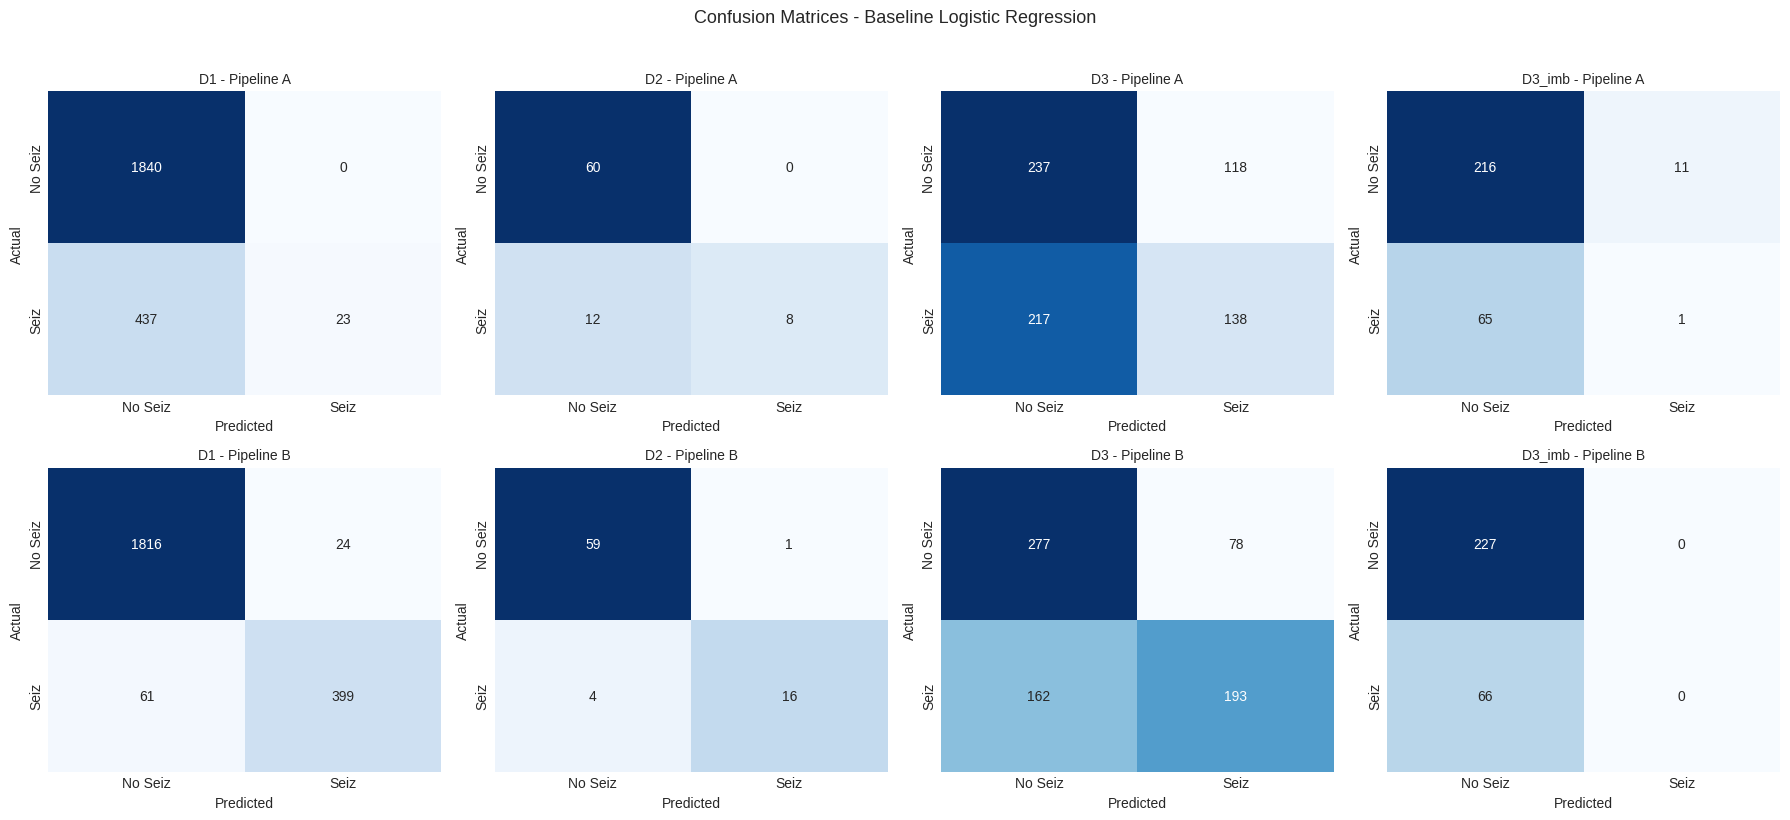

In [42]:
# Cell 26: Visualize baseline results

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

datasets_list = ['D1', 'D2', 'D3', 'D3_imb']

# Row 1: Pipeline A confusion matrices
# Row 2: Pipeline B confusion matrices
for col, ds_name in enumerate(datasets_list):
    for row, (pipe_name, pipe_data) in enumerate([('A', pipeline_A_results),
                                                    ('B', pipeline_B_results)]):
        X_tr, X_te, y_tr, y_te = pipe_data[ds_name]
        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        cm = confusion_matrix(y_te, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                    xticklabels=['No Seiz', 'Seiz'], yticklabels=['No Seiz', 'Seiz'],
                    cbar=False)
        axes[row, col].set_title(f'{ds_name} - Pipeline {pipe_name}', fontsize=10)
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - Baseline Logistic Regression', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('baseline_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

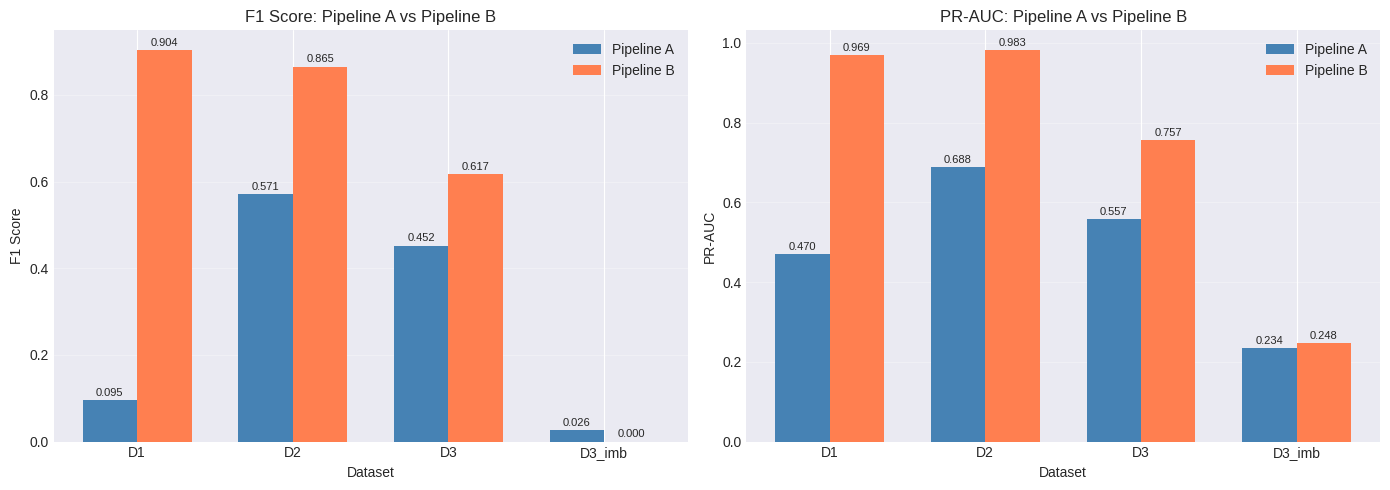


✅ Step 3: Logistic Regression Baseline - COMPLETE!
→ Next: Step 4 - Demonstrate Overfitting & Underfitting


In [43]:
# Cell 27: Bar chart comparing pipelines

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets_list = ['D1', 'D2', 'D3', 'D3_imb']
x = np.arange(len(datasets_list))
width = 0.35

# F1 Score comparison
f1_a = [results_df[(results_df['Dataset']==d) & (results_df['Pipeline']=='A')]['F1'].values[0] for d in datasets_list]
f1_b = [results_df[(results_df['Dataset']==d) & (results_df['Pipeline']=='B')]['F1'].values[0] for d in datasets_list]

axes[0].bar(x - width/2, f1_a, width, label='Pipeline A', color='steelblue')
axes[0].bar(x + width/2, f1_b, width, label='Pipeline B', color='coral')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score: Pipeline A vs Pipeline B')
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets_list)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
for i, (a, b) in enumerate(zip(f1_a, f1_b)):
    axes[0].text(i - width/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=8)

# PR-AUC comparison
pr_a = [results_df[(results_df['Dataset']==d) & (results_df['Pipeline']=='A')]['PR_AUC'].values[0] for d in datasets_list]
pr_b = [results_df[(results_df['Dataset']==d) & (results_df['Pipeline']=='B')]['PR_AUC'].values[0] for d in datasets_list]

axes[1].bar(x - width/2, pr_a, width, label='Pipeline A', color='steelblue')
axes[1].bar(x + width/2, pr_b, width, label='Pipeline B', color='coral')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('PR-AUC: Pipeline A vs Pipeline B')
axes[1].set_xticks(x)
axes[1].set_xticklabels(datasets_list)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
for i, (a, b) in enumerate(zip(pr_a, pr_b)):
    axes[1].text(i - width/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)
    axes[1].text(i + width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Step 3: Logistic Regression Baseline - COMPLETE!")
print("→ Next: Step 4 - Demonstrate Overfitting & Underfitting")

**🚀 Step 4: Demonstrate Overfitting & Underfitting**

In [44]:
# Cell 28: Setup for overfitting/underfitting analysis
from sklearn.model_selection import validation_curve, learning_curve
from sklearn.preprocessing import StandardScaler

# Hum Dataset 1 (UCI) use karenge - sabse bara aur balanced enough hai
# Original X1 use karenge (178 features) taake clear effect dikhe

print("Using Dataset 1 (UCI) for overfitting/underfitting demonstration")
print(f"Original shape: X1={X1.shape}, y1={y1.shape}")

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X1, y1, test_size=0.2,
                                            random_state=42, stratify=y1)

# Scale data (zaroori hai LR ke liye)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

print(f"After split: Train {X_tr_scaled.shape}, Test {X_te_scaled.shape}")

Using Dataset 1 (UCI) for overfitting/underfitting demonstration
Original shape: X1=(11500, 178), y1=(11500,)
After split: Train (9200, 178), Test (2300, 178)


In [45]:
# Cell 29: UNDERFITTING demonstration
# Strong regularization + only 5 features (very limited model)

print("="*70)
print("SCENARIO 1: UNDERFITTING (Strong reg + Limited features)")
print("="*70)

# Use only first 5 features (very limited)
X_tr_under = X_tr_scaled[:, :5]
X_te_under = X_te_scaled[:, :5]

print(f"Features used: only 5 out of 178")
print(f"Regularization: C=0.001 (VERY STRONG, model can't learn much)")

# Very strong regularization
model_underfit = LogisticRegression(C=0.001, max_iter=1000,
                                     penalty='l2', random_state=42)
model_underfit.fit(X_tr_under, y_tr)

# Metrics
train_acc_under = accuracy_score(y_tr, model_underfit.predict(X_tr_under))
test_acc_under = accuracy_score(y_te, model_underfit.predict(X_te_under))
f1_under = f1_score(y_te, model_underfit.predict(X_te_under))

print(f"\n  Train Accuracy: {train_acc_under:.4f}")
print(f"  Test Accuracy : {test_acc_under:.4f}")
print(f"  F1-score      : {f1_under:.4f}")
print(f"  Gap (Train-Test): {abs(train_acc_under - test_acc_under):.4f}")
print(f"\n  💡 Notice: Both train AND test accuracy are LOW")
print(f"     → Model is too simple, can't learn the pattern")
print(f"     → This is UNDERFITTING (high bias)")

SCENARIO 1: UNDERFITTING (Strong reg + Limited features)
Features used: only 5 out of 178
Regularization: C=0.001 (VERY STRONG, model can't learn much)

  Train Accuracy: 0.8000
  Test Accuracy : 0.8000
  F1-score      : 0.0000
  Gap (Train-Test): 0.0000

  💡 Notice: Both train AND test accuracy are LOW
     → Model is too simple, can't learn the pattern
     → This is UNDERFITTING (high bias)


In [46]:
# Cell 30: OVERFITTING demonstration
# No regularization + all features + small training subset

print("="*70)
print("SCENARIO 2: OVERFITTING (No reg + High dimensional)")
print("="*70)

# Use only 200 training samples but ALL 178 features
# This makes feature-to-sample ratio bad → easy to overfit
np.random.seed(42)
small_idx = np.random.choice(len(X_tr_scaled), 200, replace=False)
X_tr_over = X_tr_scaled[small_idx]
y_tr_over = y_tr[small_idx]

print(f"Training samples: only 200 (small dataset)")
print(f"Features: all 178")
print(f"Sample-to-feature ratio: 200/178 = 1.12 (VERY POOR)")
print(f"Regularization: C=10000 (effectively NO regularization)")

# No regularization (very high C)
model_overfit = LogisticRegression(C=10000, max_iter=5000,
                                    penalty='l2', random_state=42)
model_overfit.fit(X_tr_over, y_tr_over)

# Metrics
train_acc_over = accuracy_score(y_tr_over, model_overfit.predict(X_tr_over))
test_acc_over = accuracy_score(y_te, model_overfit.predict(X_te_scaled))
f1_over = f1_score(y_te, model_overfit.predict(X_te_scaled))

print(f"\n  Train Accuracy: {train_acc_over:.4f}")
print(f"  Test Accuracy : {test_acc_over:.4f}")
print(f"  F1-score      : {f1_over:.4f}")
print(f"  Gap (Train-Test): {abs(train_acc_over - test_acc_over):.4f}  ⚠ LARGE GAP")
print(f"\n  💡 Notice: Train accuracy is HIGH but test accuracy DROPS")
print(f"     → Model memorized training data, can't generalize")
print(f"     → This is OVERFITTING (high variance)")

SCENARIO 2: OVERFITTING (No reg + High dimensional)
Training samples: only 200 (small dataset)
Features: all 178
Sample-to-feature ratio: 200/178 = 1.12 (VERY POOR)
Regularization: C=10000 (effectively NO regularization)

  Train Accuracy: 1.0000
  Test Accuracy : 0.8257
  F1-score      : 0.4772
  Gap (Train-Test): 0.1743  ⚠ LARGE GAP

  💡 Notice: Train accuracy is HIGH but test accuracy DROPS
     → Model memorized training data, can't generalize
     → This is OVERFITTING (high variance)


In [47]:
# Cell 31: JUST RIGHT - good fit
print("="*70)
print("SCENARIO 3: JUST RIGHT (Moderate regularization)")
print("="*70)

print(f"Training samples: all {len(X_tr_scaled)}")
print(f"Features: all 178")
print(f"Regularization: C=1.0 (DEFAULT, balanced)")

model_good = LogisticRegression(C=1.0, max_iter=1000,
                                 penalty='l2', random_state=42)
model_good.fit(X_tr_scaled, y_tr)

train_acc_good = accuracy_score(y_tr, model_good.predict(X_tr_scaled))
test_acc_good = accuracy_score(y_te, model_good.predict(X_te_scaled))
f1_good = f1_score(y_te, model_good.predict(X_te_scaled))

print(f"\n  Train Accuracy: {train_acc_good:.4f}")
print(f"  Test Accuracy : {test_acc_good:.4f}")
print(f"  F1-score      : {f1_good:.4f}")
print(f"  Gap (Train-Test): {abs(train_acc_good - test_acc_good):.4f}  ✓ SMALL GAP")
print(f"\n  💡 Both train and test accuracy are HIGH and CLOSE")
print(f"     → Model learned the pattern AND generalizes well")
print(f"     → This is GOOD FIT")

SCENARIO 3: JUST RIGHT (Moderate regularization)
Training samples: all 9200
Features: all 178
Regularization: C=1.0 (DEFAULT, balanced)

  Train Accuracy: 0.8282
  Test Accuracy : 0.8157
  F1-score      : 0.1520
  Gap (Train-Test): 0.0125  ✓ SMALL GAP

  💡 Both train and test accuracy are HIGH and CLOSE
     → Model learned the pattern AND generalizes well
     → This is GOOD FIT


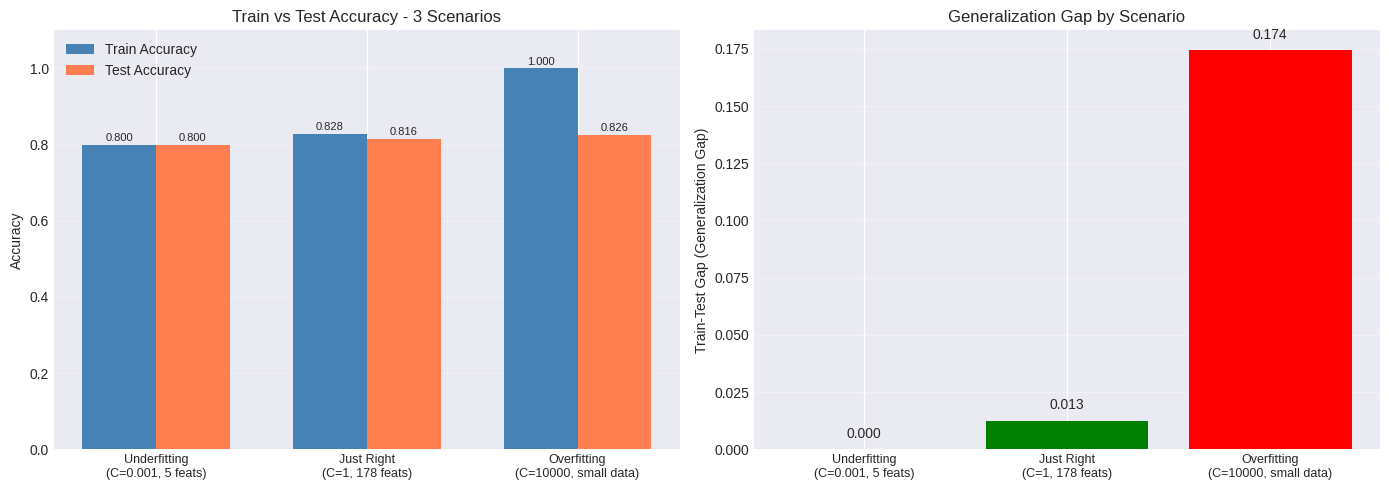


📊 Summary Table:
Scenario             Train Acc    Test Acc     Gap       
-------------------------------------------------------
Underfitting         0.8000       0.8000       0.0000    
Just Right           0.8282       0.8157       0.0125    
Overfitting          1.0000       0.8257       0.1743    


In [48]:
# Cell 32: Visualize all 3 scenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scenarios = ['Underfitting\n(C=0.001, 5 feats)',
             'Just Right\n(C=1, 178 feats)',
             'Overfitting\n(C=10000, small data)']
train_accs = [train_acc_under, train_acc_good, train_acc_over]
test_accs = [test_acc_under, test_acc_good, test_acc_over]

x = np.arange(len(scenarios))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_accs, width, label='Train Accuracy', color='steelblue')
bars2 = axes[0].bar(x + width/2, test_accs, width, label='Test Accuracy', color='coral')

axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy - 3 Scenarios')
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenarios, fontsize=9)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim([0, 1.1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.01,
                     f'{height:.3f}', ha='center', fontsize=8)

# Plot 2: Gap visualization
gaps = [abs(t-te) for t, te in zip(train_accs, test_accs)]
colors_gap = ['orange', 'green', 'red']
axes[1].bar(scenarios, gaps, color=colors_gap)
axes[1].set_ylabel('Train-Test Gap (Generalization Gap)')
axes[1].set_title('Generalization Gap by Scenario')
axes[1].set_xticklabels(scenarios, fontsize=9)
axes[1].grid(alpha=0.3, axis='y')

for i, gap in enumerate(gaps):
    axes[1].text(i, gap + 0.005, f'{gap:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('overfitting_underfitting_scenarios.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 Summary Table:")
print(f"{'Scenario':<20} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<10}")
print("-"*55)
for s, tr, te in zip(['Underfitting', 'Just Right', 'Overfitting'],
                      train_accs, test_accs):
    print(f"{s:<20} {tr:<12.4f} {te:<12.4f} {abs(tr-te):<10.4f}")

VALIDATION CURVE: How C (regularization) affects performance
Computing validation curves... (yeh thoda time lega)


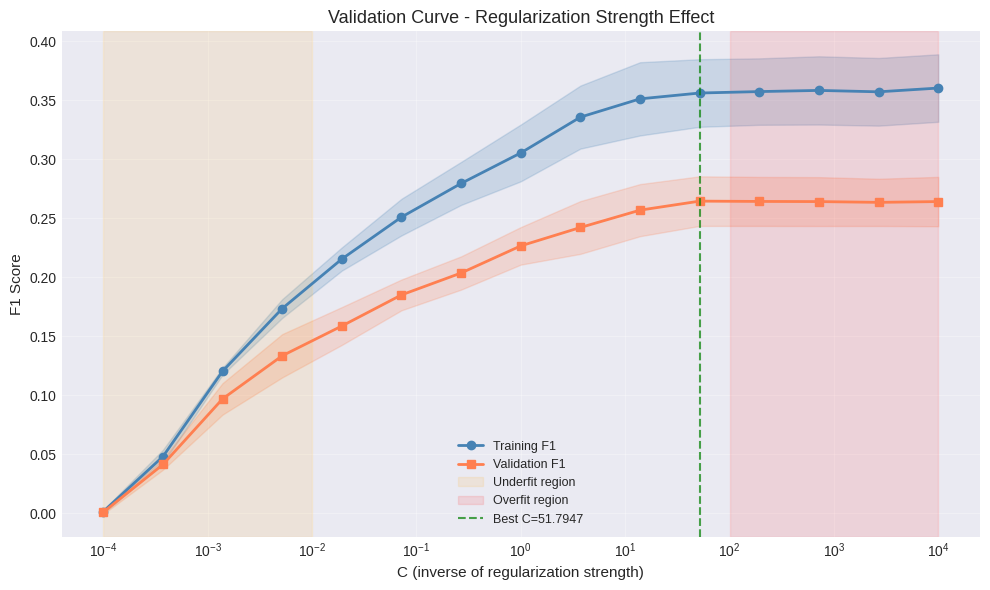


💡 Key insights:
   - Very small C (left): Strong reg → Underfitting (low train + low val)
   - Very large C (right): No reg → Overfitting (high train, low val)
   - Best C = 51.7947 (peak validation F1)


In [49]:
# Cell 33: Validation curve - C parameter ka effect
print("="*70)
print("VALIDATION CURVE: How C (regularization) affects performance")
print("="*70)

# Range of C values from very strong reg to no reg
C_range = np.logspace(-4, 4, 15)  # 0.0001 to 10000

print("Computing validation curves... (yeh thoda time lega)")
train_scores, val_scores = validation_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_tr_scaled, y_tr,
    param_name='C',
    param_range=C_range,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(C_range, train_mean, 'o-', color='steelblue', label='Training F1', linewidth=2)
ax.fill_between(C_range, train_mean-train_std, train_mean+train_std, alpha=0.2, color='steelblue')

ax.semilogx(C_range, val_mean, 's-', color='coral', label='Validation F1', linewidth=2)
ax.fill_between(C_range, val_mean-val_std, val_mean+val_std, alpha=0.2, color='coral')

# Annotate regions
ax.axvspan(1e-4, 1e-2, alpha=0.1, color='orange', label='Underfit region')
ax.axvspan(1e2, 1e4, alpha=0.1, color='red', label='Overfit region')

# Mark best
best_C = C_range[np.argmax(val_mean)]
ax.axvline(best_C, linestyle='--', color='green', alpha=0.7, label=f'Best C={best_C:.4f}')

ax.set_xlabel('C (inverse of regularization strength)', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Validation Curve - Regularization Strength Effect', fontsize=13)
ax.legend(loc='lower center', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('validation_curve.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n💡 Key insights:")
print(f"   - Very small C (left): Strong reg → Underfitting (low train + low val)")
print(f"   - Very large C (right): No reg → Overfitting (high train, low val)")
print(f"   - Best C = {best_C:.4f} (peak validation F1)")

LEARNING CURVE: How training data size affects performance
Computing learning curves... (thoda time lega)


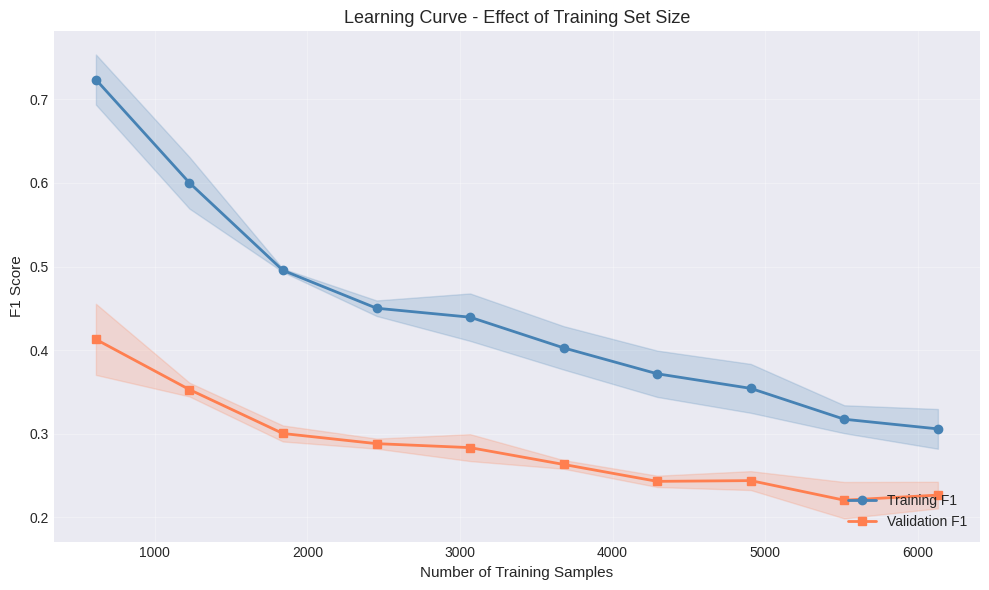


💡 Learning curve insights:
   - Initial gap (small data): 0.3107
   - Final gap (full data)   : 0.0792
   - Large gap → Model could benefit from MORE data or regularization

✅ Step 4: Overfitting & Underfitting - COMPLETE!
→ Next: Step 5 - Regularization Study (L1, L2, Elastic Net)


In [50]:
# Cell 34: Learning curve - training size ka effect
print("="*70)
print("LEARNING CURVE: How training data size affects performance")
print("="*70)

train_sizes = np.linspace(0.1, 1.0, 10)

print("Computing learning curves... (thoda time lega)")
train_sizes_abs, train_scores_lc, val_scores_lc = learning_curve(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    X_tr_scaled, y_tr,
    train_sizes=train_sizes,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

train_mean_lc = train_scores_lc.mean(axis=1)
train_std_lc = train_scores_lc.std(axis=1)
val_mean_lc = val_scores_lc.mean(axis=1)
val_std_lc = val_scores_lc.std(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes_abs, train_mean_lc, 'o-', color='steelblue', label='Training F1', linewidth=2)
ax.fill_between(train_sizes_abs, train_mean_lc-train_std_lc, train_mean_lc+train_std_lc,
                alpha=0.2, color='steelblue')

ax.plot(train_sizes_abs, val_mean_lc, 's-', color='coral', label='Validation F1', linewidth=2)
ax.fill_between(train_sizes_abs, val_mean_lc-val_std_lc, val_mean_lc+val_std_lc,
                alpha=0.2, color='coral')

ax.set_xlabel('Number of Training Samples', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Learning Curve - Effect of Training Set Size', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Gap analysis
final_gap = abs(train_mean_lc[-1] - val_mean_lc[-1])
print(f"\n💡 Learning curve insights:")
print(f"   - Initial gap (small data): {abs(train_mean_lc[0] - val_mean_lc[0]):.4f}")
print(f"   - Final gap (full data)   : {final_gap:.4f}")
if final_gap > 0.05:
    print(f"   - Large gap → Model could benefit from MORE data or regularization")
elif final_gap < 0.02:
    print(f"   - Small gap → Model is well-fit, more data won't help much")
else:
    print(f"   - Moderate gap → Reasonable fit")

print("\n✅ Step 4: Overfitting & Underfitting - COMPLETE!")
print("→ Next: Step 5 - Regularization Study (L1, L2, Elastic Net)")

**🚀 Step 5: Regularization Study (L1, L2, Elastic Net)**

In [51]:
# Cell 35: Setup for regularization comparison
from sklearn.linear_model import LogisticRegression

# We'll use Pipeline A results (50 features) for fair comparison across all datasets
print("Using Pipeline A preprocessed data for regularization study")
print("(50 features per dataset - fair comparison)\n")

for name in pipeline_A_results.keys():
    X_tr, X_te, y_tr, y_te = pipeline_A_results[name]
    print(f"  {name}: Train {X_tr.shape}, Test {X_te.shape}")

# Function to train all 3 regularization types
def train_regularization_models(X_tr, X_te, y_tr, y_te, dataset_name):
    """
    Train L1, L2, and Elastic Net logistic regression.
    Returns metrics dict and models dict.
    """
    results = []
    models = {}

    # L1 (Lasso) - liblinear or saga solver supports L1
    print(f"\n  Training L1 (Lasso)...")
    model_l1 = LogisticRegression(penalty='l1', C=1.0, solver='liblinear',
                                    max_iter=2000, random_state=42)
    metrics_l1, _, _, _ = evaluate_model(model_l1, X_tr, X_te, y_tr, y_te, 'L1')
    metrics_l1['Dataset'] = dataset_name
    metrics_l1['Regularization'] = 'L1 (Lasso)'
    metrics_l1['Sparsity'] = (model_l1.coef_ == 0).sum() / model_l1.coef_.size * 100
    metrics_l1['Non_zero_features'] = (model_l1.coef_ != 0).sum()
    results.append(metrics_l1)
    models['L1'] = model_l1

    # L2 (Ridge) - default
    print(f"  Training L2 (Ridge)...")
    model_l2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                    max_iter=2000, random_state=42)
    metrics_l2, _, _, _ = evaluate_model(model_l2, X_tr, X_te, y_tr, y_te, 'L2')
    metrics_l2['Dataset'] = dataset_name
    metrics_l2['Regularization'] = 'L2 (Ridge)'
    metrics_l2['Sparsity'] = (model_l2.coef_ == 0).sum() / model_l2.coef_.size * 100
    metrics_l2['Non_zero_features'] = (model_l2.coef_ != 0).sum()
    results.append(metrics_l2)
    models['L2'] = model_l2

    # Elastic Net (saga solver supports it, l1_ratio = mix)
    print(f"  Training Elastic Net (50/50)...")
    model_en = LogisticRegression(penalty='elasticnet', C=1.0, solver='saga',
                                    l1_ratio=0.5, max_iter=2000, random_state=42)
    metrics_en, _, _, _ = evaluate_model(model_en, X_tr, X_te, y_tr, y_te, 'ElasticNet')
    metrics_en['Dataset'] = dataset_name
    metrics_en['Regularization'] = 'Elastic Net'
    metrics_en['Sparsity'] = (model_en.coef_ == 0).sum() / model_en.coef_.size * 100
    metrics_en['Non_zero_features'] = (model_en.coef_ != 0).sum()
    results.append(metrics_en)
    models['ElasticNet'] = model_en

    return results, models

print("\n✅ Setup complete - ready to train regularization models")

Using Pipeline A preprocessed data for regularization study
(50 features per dataset - fair comparison)

  D1: Train (9200, 50), Test (2300, 50)
  D2: Train (320, 50), Test (80, 50)
  D3: Train (2836, 50), Test (710, 50)
  D3_imb: Train (1169, 50), Test (293, 50)

✅ Setup complete - ready to train regularization models


In [52]:
# Cell 36: Train L1, L2, ElasticNet on all 4 datasets

print("="*70)
print("TRAINING REGULARIZATION MODELS - ALL DATASETS")
print("="*70)

all_reg_results = []
all_reg_models = {}

for name, (X_tr, X_te, y_tr, y_te) in pipeline_A_results.items():
    print(f"\n{'─'*50}")
    print(f"Dataset: {name}")
    print(f"{'─'*50}")

    results, models = train_regularization_models(X_tr, X_te, y_tr, y_te, name)
    all_reg_results.extend(results)
    all_reg_models[name] = models

    # Print quick summary
    for r in results:
        print(f"\n  {r['Regularization']:<15}: F1={r['F1']:.4f}, PR-AUC={r['PR_AUC']:.4f}, "
              f"Sparsity={r['Sparsity']:.1f}%")

print("\n✅ All models trained!")

TRAINING REGULARIZATION MODELS - ALL DATASETS

──────────────────────────────────────────────────
Dataset: D1
──────────────────────────────────────────────────

  Training L1 (Lasso)...
  Training L2 (Ridge)...
  Training Elastic Net (50/50)...

  L1 (Lasso)     : F1=0.0913, PR-AUC=0.4706, Sparsity=26.0%

  L2 (Ridge)     : F1=0.0952, PR-AUC=0.4701, Sparsity=0.0%

  Elastic Net    : F1=0.0952, PR-AUC=0.4706, Sparsity=14.0%

──────────────────────────────────────────────────
Dataset: D2
──────────────────────────────────────────────────

  Training L1 (Lasso)...
  Training L2 (Ridge)...
  Training Elastic Net (50/50)...

  L1 (Lasso)     : F1=0.4615, PR-AUC=0.6835, Sparsity=48.0%

  L2 (Ridge)     : F1=0.5714, PR-AUC=0.6882, Sparsity=0.0%

  Elastic Net    : F1=0.5185, PR-AUC=0.6839, Sparsity=22.0%

──────────────────────────────────────────────────
Dataset: D3
──────────────────────────────────────────────────

  Training L1 (Lasso)...
  Training L2 (Ridge)...
  Training Elastic Net (

In [53]:
# Cell 37: Build complete comparison table
reg_df = pd.DataFrame(all_reg_results)
cols = ['Dataset', 'Regularization', 'Train_Accuracy', 'Test_Accuracy',
        'F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC',
        'Sparsity', 'Non_zero_features']
reg_df = reg_df[cols]

print("="*100)
print("REGULARIZATION COMPARISON - ALL RESULTS")
print("="*100)
print(reg_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

reg_df.to_csv(save_path + 'regularization_results.csv', index=False)
print(f"\n✅ Saved to: regularization_results.csv")

REGULARIZATION COMPARISON - ALL RESULTS
Dataset Regularization  Train_Accuracy  Test_Accuracy     F1  Precision  Recall  PR_AUC  ROC_AUC  Sparsity  Non_zero_features
     D1     L1 (Lasso)          0.8146         0.8096 0.0913     1.0000  0.0478  0.4706   0.5141   26.0000                 37
     D1     L2 (Ridge)          0.8154         0.8100 0.0952     1.0000  0.0500  0.4701   0.5129    0.0000                 50
     D1    Elastic Net          0.8148         0.8100 0.0952     1.0000  0.0500  0.4706   0.5138   14.0000                 43
     D2     L1 (Lasso)          0.9313         0.8250 0.4615     1.0000  0.3000  0.6835   0.6075   48.0000                 26
     D2     L2 (Ridge)          0.9406         0.8500 0.5714     1.0000  0.4000  0.6882   0.6133    0.0000                 50
     D2    Elastic Net          0.9344         0.8375 0.5185     1.0000  0.3500  0.6839   0.6100   22.0000                 39
     D3     L1 (Lasso)          0.5927         0.5113 0.4207     0.5164  0.354

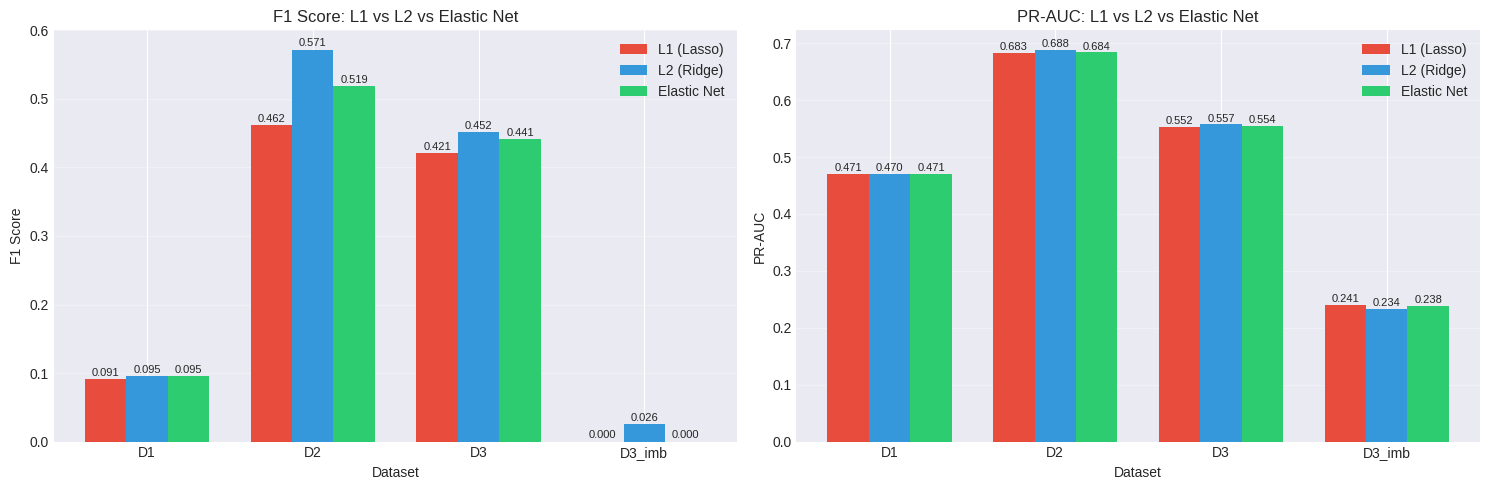

In [54]:
# Cell 38: Bar chart - regularization comparison

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

datasets_list = ['D1', 'D2', 'D3', 'D3_imb']
reg_types = ['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net']
colors_reg = ['#e74c3c', '#3498db', '#2ecc71']

x = np.arange(len(datasets_list))
width = 0.25

# F1 comparison
for i, reg in enumerate(reg_types):
    f1_vals = [reg_df[(reg_df['Dataset']==d) & (reg_df['Regularization']==reg)]['F1'].values[0]
               for d in datasets_list]
    axes[0].bar(x + i*width - width, f1_vals, width, label=reg, color=colors_reg[i])
    for j, v in enumerate(f1_vals):
        axes[0].text(j + i*width - width, v + 0.005, f'{v:.3f}',
                     ha='center', fontsize=8)

axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score: L1 vs L2 vs Elastic Net')
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets_list)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# PR-AUC comparison
for i, reg in enumerate(reg_types):
    pr_vals = [reg_df[(reg_df['Dataset']==d) & (reg_df['Regularization']==reg)]['PR_AUC'].values[0]
               for d in datasets_list]
    axes[1].bar(x + i*width - width, pr_vals, width, label=reg, color=colors_reg[i])
    for j, v in enumerate(pr_vals):
        axes[1].text(j + i*width - width, v + 0.005, f'{v:.3f}',
                     ha='center', fontsize=8)

axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('PR-AUC: L1 vs L2 vs Elastic Net')
axes[1].set_xticks(x)
axes[1].set_xticklabels(datasets_list)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

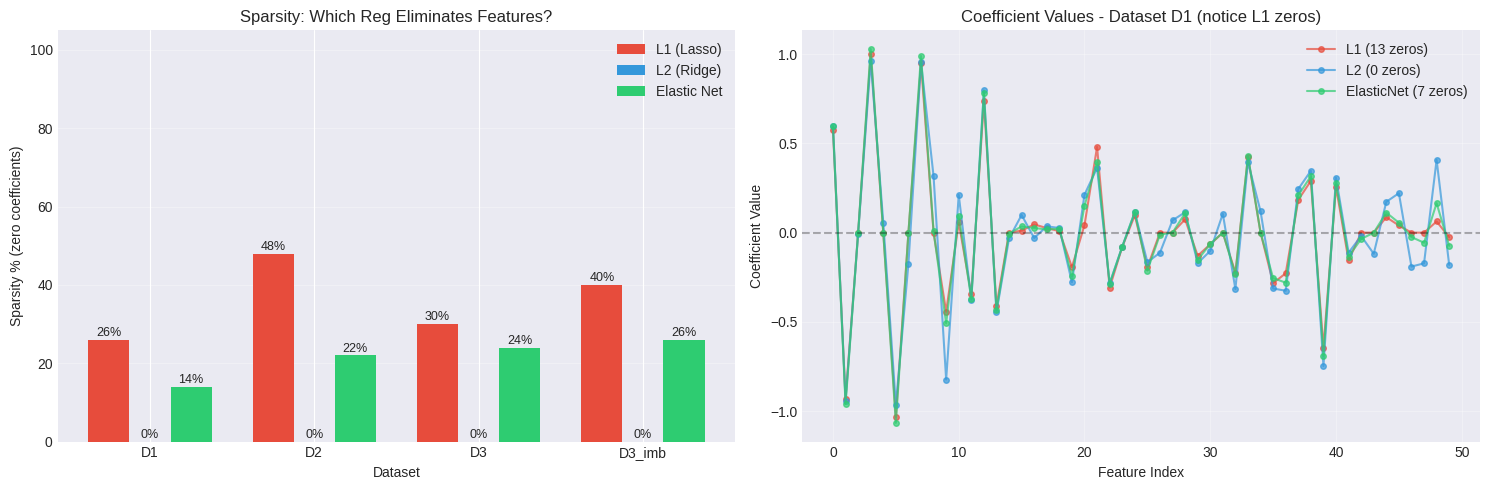


💡 SPARSITY INSIGHTS:
  L1 (Lasso): Zeros out features → automatic feature selection
  L2 (Ridge): Shrinks but rarely zeros → keeps all features
  Elastic Net: Balance - some zeros, smoother shrinkage


In [55]:
# Cell 39: Sparsity analysis - kitne features zero hue

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Sparsity percentage
sparsity_data = []
for d in datasets_list:
    for reg in reg_types:
        sp = reg_df[(reg_df['Dataset']==d) & (reg_df['Regularization']==reg)]['Sparsity'].values[0]
        sparsity_data.append({'Dataset': d, 'Regularization': reg, 'Sparsity': sp})

sp_df = pd.DataFrame(sparsity_data)

x = np.arange(len(datasets_list))
width = 0.25

for i, reg in enumerate(reg_types):
    sps = [sp_df[(sp_df['Dataset']==d) & (sp_df['Regularization']==reg)]['Sparsity'].values[0]
           for d in datasets_list]
    axes[0].bar(x + i*width - width, sps, width, label=reg, color=colors_reg[i])
    for j, v in enumerate(sps):
        axes[0].text(j + i*width - width, v + 1, f'{v:.0f}%',
                     ha='center', fontsize=9)

axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Sparsity % (zero coefficients)')
axes[0].set_title('Sparsity: Which Reg Eliminates Features?')
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets_list)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim([0, 105])

# Plot 2: Coefficient distribution for D1 (visual sparsity)
ax2 = axes[1]
d1_models = all_reg_models['D1']
for i, (reg_name, model) in enumerate(d1_models.items()):
    coefs = model.coef_.flatten()
    ax2.plot(np.arange(len(coefs)), coefs, 'o-',
             label=f'{reg_name} ({(coefs==0).sum()} zeros)',
             color=colors_reg[i], alpha=0.7, markersize=4)

ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('Feature Index')
ax2.set_ylabel('Coefficient Value')
ax2.set_title('Coefficient Values - Dataset D1 (notice L1 zeros)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sparsity_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n💡 SPARSITY INSIGHTS:")
print("  L1 (Lasso): Zeros out features → automatic feature selection")
print("  L2 (Ridge): Shrinks but rarely zeros → keeps all features")
print("  Elastic Net: Balance - some zeros, smoother shrinkage")

STABILITY ANALYSIS - Performance Consistency Across Datasets
Regularization  F1_Mean  F1_Std  F1_Min  F1_Max  PR_AUC_Mean  PR_AUC_Std
    L1 (Lasso)   0.2434  0.2009  0.0000  0.4615       0.4867      0.1611
    L2 (Ridge)   0.2860  0.2308  0.0256  0.5714       0.4873      0.1658
   Elastic Net   0.2636  0.2203  0.0000  0.5185       0.4866      0.1625


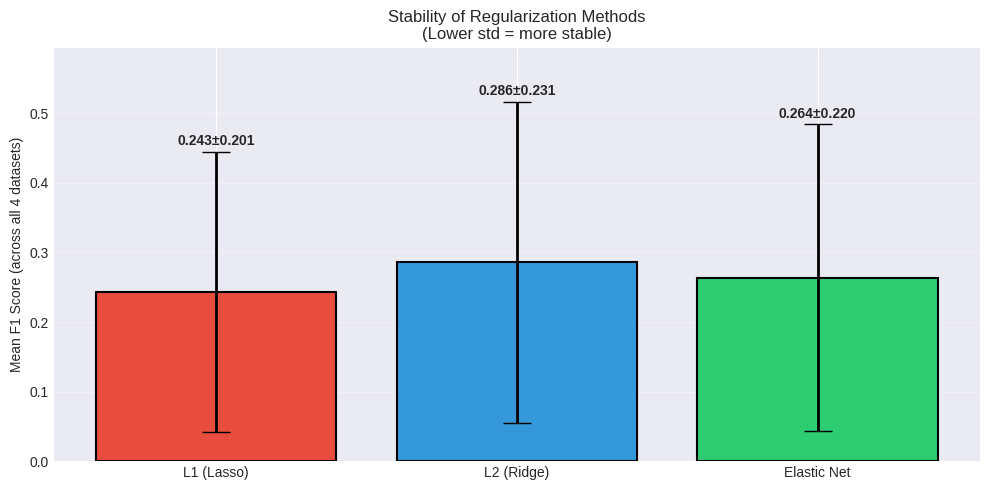


🏆 Best mean F1: L2 (Ridge)
🎯 Most stable (lowest std): L1 (Lasso)


In [56]:
# Cell 40: Stability - which regularization is most consistent?

# Calculate F1 mean and std across datasets for each regularization
stability_data = []
for reg in reg_types:
    f1s = reg_df[reg_df['Regularization']==reg]['F1'].values
    pr_aucs = reg_df[reg_df['Regularization']==reg]['PR_AUC'].values
    stability_data.append({
        'Regularization': reg,
        'F1_Mean': f1s.mean(),
        'F1_Std': f1s.std(),
        'F1_Min': f1s.min(),
        'F1_Max': f1s.max(),
        'PR_AUC_Mean': pr_aucs.mean(),
        'PR_AUC_Std': pr_aucs.std()
    })

stab_df = pd.DataFrame(stability_data)
print("="*70)
print("STABILITY ANALYSIS - Performance Consistency Across Datasets")
print("="*70)
print(stab_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(reg_types))
means = stab_df['F1_Mean'].values
stds = stab_df['F1_Std'].values

bars = ax.bar(x_pos, means, yerr=stds, capsize=10,
              color=colors_reg, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.01, f'{m:.3f}±{s:.3f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(reg_types)
ax.set_ylabel('Mean F1 Score (across all 4 datasets)')
ax.set_title('Stability of Regularization Methods\n(Lower std = more stable)')
ax.grid(alpha=0.3, axis='y')
ax.set_ylim([0, max(means + stds) * 1.15])

plt.tight_layout()
plt.savefig('stability_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# Determine winner
best_mean = stab_df.loc[stab_df['F1_Mean'].idxmax(), 'Regularization']
most_stable = stab_df.loc[stab_df['F1_Std'].idxmin(), 'Regularization']

print(f"\n🏆 Best mean F1: {best_mean}")
print(f"🎯 Most stable (lowest std): {most_stable}")

In [57]:
# Cell 41: Save regularization results

# Save dataframes
stab_df.to_csv(save_path + 'stability_analysis.csv', index=False)
sp_df.to_csv(save_path + 'sparsity_analysis.csv', index=False)

# Save models for later use (optional)
import pickle
with open(save_path + 'all_reg_models.pkl', 'wb') as f:
    pickle.dump(all_reg_models, f)

print("✅ Saved files:")
print("   - regularization_results.csv (main comparison)")
print("   - stability_analysis.csv (stability metrics)")
print("   - sparsity_analysis.csv (feature sparsity)")
print("   - all_reg_models.pkl (trained models)")

print("\n" + "="*70)
print("STEP 5 ANSWERS (for your report):")
print("="*70)

print("\n1. Which regularization wins on each dataset?")
for d in datasets_list:
    best_reg = reg_df[reg_df['Dataset']==d].loc[reg_df[reg_df['Dataset']==d]['F1'].idxmax(), 'Regularization']
    best_f1 = reg_df[reg_df['Dataset']==d]['F1'].max()
    print(f"   {d}: {best_reg} (F1={best_f1:.4f})")

print(f"\n2. Most stable across datasets: {most_stable}")
print(f"   (lowest std deviation in F1)")

print(f"\n3. Sparsity comparison (D1 example):")
for reg in reg_types:
    sp = sp_df[(sp_df['Dataset']=='D1') & (sp_df['Regularization']==reg)]['Sparsity'].values[0]
    print(f"   {reg}: {sp:.0f}% features zeroed")

print("\n✅ Step 5: Regularization Study - COMPLETE!")
print("→ Next: Step 6 - Class Imbalance Handling (SMOTE, Class Weighting)")

✅ Saved files:
   - regularization_results.csv (main comparison)
   - stability_analysis.csv (stability metrics)
   - sparsity_analysis.csv (feature sparsity)
   - all_reg_models.pkl (trained models)

STEP 5 ANSWERS (for your report):

1. Which regularization wins on each dataset?
   D1: L2 (Ridge) (F1=0.0952)
   D2: L2 (Ridge) (F1=0.5714)
   D3: L2 (Ridge) (F1=0.4517)
   D3_imb: L2 (Ridge) (F1=0.0256)

2. Most stable across datasets: L1 (Lasso)
   (lowest std deviation in F1)

3. Sparsity comparison (D1 example):
   L1 (Lasso): 26% features zeroed
   L2 (Ridge): 0% features zeroed
   Elastic Net: 14% features zeroed

✅ Step 5: Regularization Study - COMPLETE!
→ Next: Step 6 - Class Imbalance Handling (SMOTE, Class Weighting)


In [58]:
# Cell 42: Diagnose the low F1 issue + use Pipeline B for comparison

print("="*70)
print("DIAGNOSTIC: Pipeline A vs Pipeline B for Regularization")
print("="*70)

# Train regularization on Pipeline B too (just for comparison)
all_reg_results_B = []
for name, (X_tr, X_te, y_tr, y_te) in pipeline_B_results.items():
    print(f"\n>>> Dataset {name} (Pipeline B):")

    # L2 only for quick check
    model_l2 = LogisticRegression(penalty='l2', C=1.0, max_iter=2000, random_state=42)
    metrics, _, _, _ = evaluate_model(model_l2, X_tr, X_te, y_tr, y_te, 'L2_PipeB')
    print(f"  Pipeline B - L2: F1={metrics['F1']:.4f}, PR-AUC={metrics['PR_AUC']:.4f}")

# Compare with baseline (no preprocessing pipeline) for D1
print(f"\n>>> Sanity check: Raw scaled data (no pipeline) on D1:")
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(X1, y1, test_size=0.2,
                                                            random_state=42, stratify=y1)
sc = StandardScaler()
X_tr_raw_s = sc.fit_transform(X_tr_raw)
X_te_raw_s = sc.transform(X_te_raw)

model_raw = LogisticRegression(penalty='l2', C=1.0, max_iter=2000, random_state=42)
metrics_raw, _, _, _ = evaluate_model(model_raw, X_tr_raw_s, X_te_raw_s, y_tr_raw, y_te_raw, 'Raw')
print(f"  Raw scaled D1 - L2: F1={metrics_raw['F1']:.4f}, PR-AUC={metrics_raw['PR_AUC']:.4f}")
print(f"  → Yeh Pipeline A se behtar hai → Pipeline A ka filter destructive hai for UCI")

DIAGNOSTIC: Pipeline A vs Pipeline B for Regularization

>>> Dataset D1 (Pipeline B):
  Pipeline B - L2: F1=0.9037, PR-AUC=0.9691

>>> Dataset D2 (Pipeline B):
  Pipeline B - L2: F1=0.8649, PR-AUC=0.9826

>>> Dataset D3 (Pipeline B):
  Pipeline B - L2: F1=0.6166, PR-AUC=0.7571

>>> Dataset D3_imb (Pipeline B):
  Pipeline B - L2: F1=0.0000, PR-AUC=0.2480

>>> Sanity check: Raw scaled data (no pipeline) on D1:
  Raw scaled D1 - L2: F1=0.1520, PR-AUC=0.4312
  → Yeh Pipeline A se behtar hai → Pipeline A ka filter destructive hai for UCI


**🚀 Step 5 Redux: Regularization Study with Pipeline B**

In [59]:
# Cell 43: Regularization study using BETTER preprocessed data (Pipeline B)

print("="*70)
print("REGULARIZATION STUDY - PIPELINE B (Better Preprocessing)")
print("="*70)

all_reg_results_B = []
all_reg_models_B = {}

for name, (X_tr, X_te, y_tr, y_te) in pipeline_B_results.items():
    print(f"\n{'─'*50}")
    print(f"Dataset: {name} | Train shape: {X_tr.shape}")
    print(f"{'─'*50}")

    results, models = train_regularization_models(X_tr, X_te, y_tr, y_te, name)

    # Mark these as Pipeline B
    for r in results:
        r['Pipeline'] = 'B'

    all_reg_results_B.extend(results)
    all_reg_models_B[name] = models

    for r in results:
        print(f"  {r['Regularization']:<15}: F1={r['F1']:.4f}, "
              f"PR-AUC={r['PR_AUC']:.4f}, Sparsity={r['Sparsity']:.1f}%")

# Combined dataframe with both pipelines
for r in all_reg_results:
    r['Pipeline'] = 'A'

reg_df_combined = pd.DataFrame(all_reg_results + all_reg_results_B)
cols = ['Dataset', 'Pipeline', 'Regularization', 'Train_Accuracy', 'Test_Accuracy',
        'F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC', 'Sparsity']
reg_df_combined = reg_df_combined[cols]

print("\n" + "="*100)
print("COMPLETE REGULARIZATION TABLE (Pipeline A & B)")
print("="*100)
print(reg_df_combined.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

reg_df_combined.to_csv(save_path + 'regularization_complete.csv', index=False)

REGULARIZATION STUDY - PIPELINE B (Better Preprocessing)

──────────────────────────────────────────────────
Dataset: D1 | Train shape: (9200, 10)
──────────────────────────────────────────────────

  Training L1 (Lasso)...
  Training L2 (Ridge)...
  Training Elastic Net (50/50)...
  L1 (Lasso)     : F1=0.9042, PR-AUC=0.9691, Sparsity=0.0%
  L2 (Ridge)     : F1=0.9037, PR-AUC=0.9691, Sparsity=0.0%
  Elastic Net    : F1=0.9037, PR-AUC=0.9691, Sparsity=0.0%

──────────────────────────────────────────────────
Dataset: D2 | Train shape: (320, 10)
──────────────────────────────────────────────────

  Training L1 (Lasso)...
  Training L2 (Ridge)...
  Training Elastic Net (50/50)...
  L1 (Lasso)     : F1=0.8649, PR-AUC=0.9815, Sparsity=40.0%
  L2 (Ridge)     : F1=0.8649, PR-AUC=0.9826, Sparsity=0.0%
  Elastic Net    : F1=0.8649, PR-AUC=0.9846, Sparsity=10.0%

──────────────────────────────────────────────────
Dataset: D3 | Train shape: (2836, 10)
──────────────────────────────────────────────

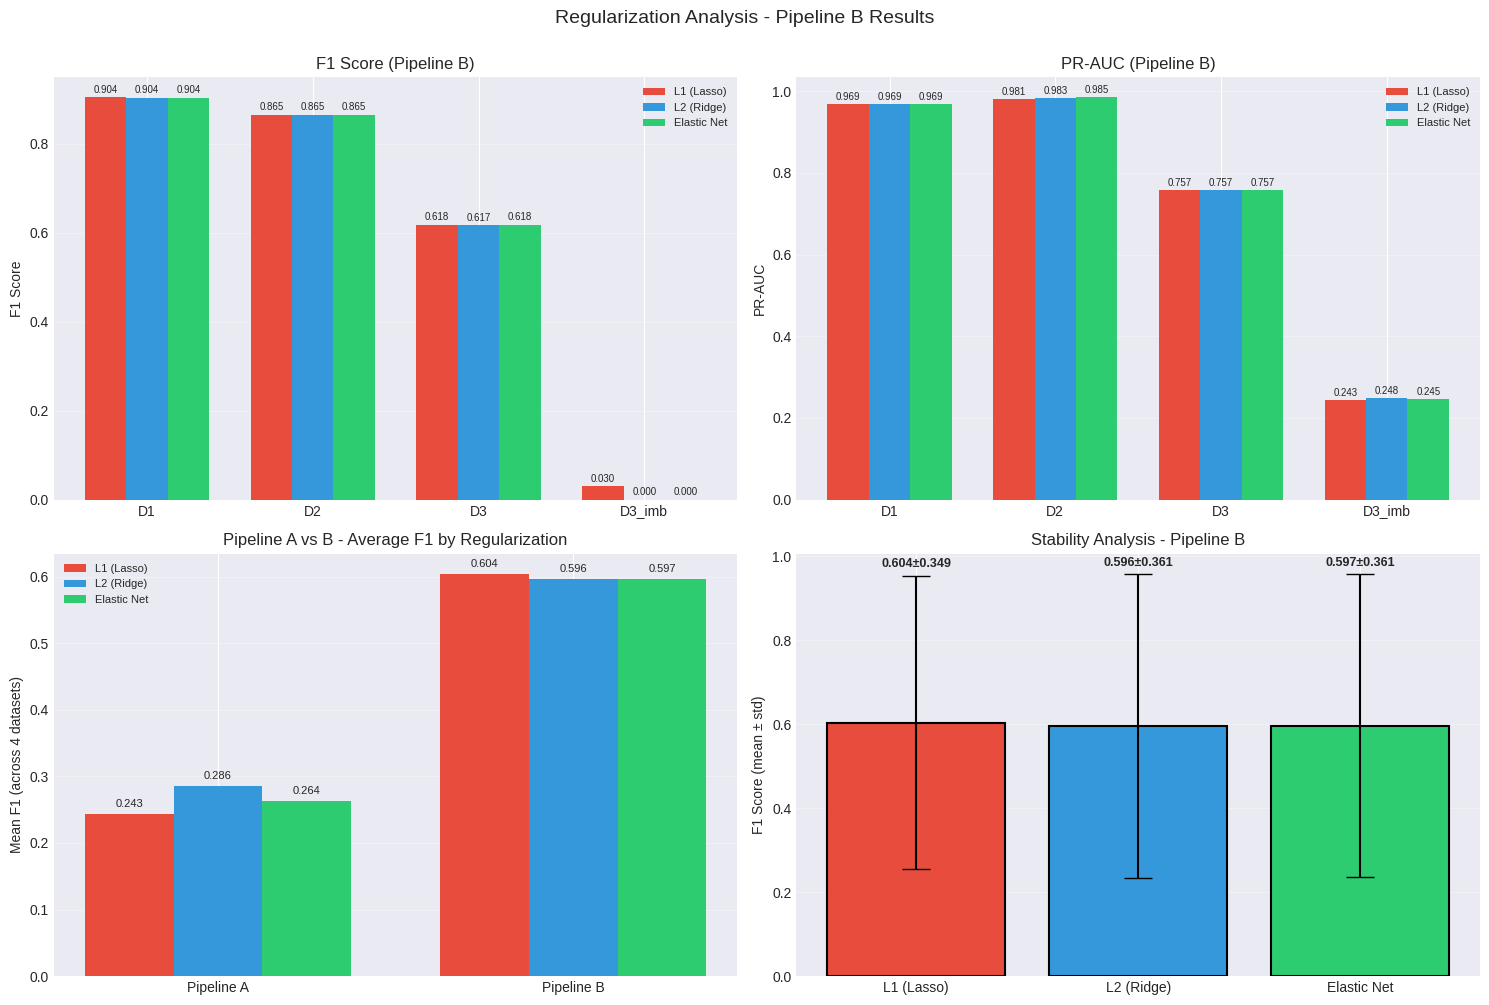


STEP 5 (PIPELINE B) - KEY INSIGHTS:
  D1: Best = L1 (Lasso) (F1=0.9042)
  D2: Best = L1 (Lasso) (F1=0.8649)
  D3: Best = L1 (Lasso) (F1=0.6176)
  D3_imb: Best = L1 (Lasso) (F1=0.0299)

  Most stable on Pipeline B: L1 (Lasso)
  Best mean F1 on Pipeline B: L1 (Lasso)

✅ Step 5 (Pipeline B) - COMPLETE!
→ Next: Step 6 - Class Imbalance Handling (CRITICAL for D3_imb)


In [60]:
# Cell 44: Pipeline B regularization comparison plots

reg_b_df = reg_df_combined[reg_df_combined['Pipeline']=='B'].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

datasets_list = ['D1', 'D2', 'D3', 'D3_imb']
reg_types = ['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net']
colors_reg = ['#e74c3c', '#3498db', '#2ecc71']

x = np.arange(len(datasets_list))
width = 0.25

# Plot 1: F1 Score
ax = axes[0, 0]
for i, reg in enumerate(reg_types):
    vals = [reg_b_df[(reg_b_df['Dataset']==d) & (reg_b_df['Regularization']==reg)]['F1'].values[0]
            for d in datasets_list]
    ax.bar(x + i*width - width, vals, width, label=reg, color=colors_reg[i])
    for j, v in enumerate(vals):
        ax.text(j + i*width - width, v + 0.01, f'{v:.3f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(datasets_list)
ax.set_ylabel('F1 Score'); ax.set_title('F1 Score (Pipeline B)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# Plot 2: PR-AUC
ax = axes[0, 1]
for i, reg in enumerate(reg_types):
    vals = [reg_b_df[(reg_b_df['Dataset']==d) & (reg_b_df['Regularization']==reg)]['PR_AUC'].values[0]
            for d in datasets_list]
    ax.bar(x + i*width - width, vals, width, label=reg, color=colors_reg[i])
    for j, v in enumerate(vals):
        ax.text(j + i*width - width, v + 0.01, f'{v:.3f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(datasets_list)
ax.set_ylabel('PR-AUC'); ax.set_title('PR-AUC (Pipeline B)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# Plot 3: Pipeline A vs B for each regularization (averaged)
ax = axes[1, 0]
pipeline_comparison = []
for pipe in ['A', 'B']:
    for reg in reg_types:
        avg_f1 = reg_df_combined[(reg_df_combined['Pipeline']==pipe) &
                                  (reg_df_combined['Regularization']==reg)]['F1'].mean()
        pipeline_comparison.append({'Pipeline': pipe, 'Reg': reg, 'F1': avg_f1})

pc_df = pd.DataFrame(pipeline_comparison)
pipeline_x = np.arange(2)
for i, reg in enumerate(reg_types):
    vals = [pc_df[(pc_df['Pipeline']==p) & (pc_df['Reg']==reg)]['F1'].values[0] for p in ['A','B']]
    ax.bar(pipeline_x + i*width - width, vals, width, label=reg, color=colors_reg[i])
    for j, v in enumerate(vals):
        ax.text(j + i*width - width, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
ax.set_xticks(pipeline_x)
ax.set_xticklabels(['Pipeline A', 'Pipeline B'])
ax.set_ylabel('Mean F1 (across 4 datasets)')
ax.set_title('Pipeline A vs B - Average F1 by Regularization')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# Plot 4: Stability (std across datasets) for Pipeline B
ax = axes[1, 1]
stability_b = []
for reg in reg_types:
    f1s = reg_b_df[reg_b_df['Regularization']==reg]['F1'].values
    stability_b.append({'Reg': reg, 'Mean': f1s.mean(), 'Std': f1s.std()})

stab_b_df = pd.DataFrame(stability_b)
bars = ax.bar(np.arange(len(reg_types)), stab_b_df['Mean'],
              yerr=stab_b_df['Std'], capsize=10,
              color=colors_reg, edgecolor='black', linewidth=1.5)
for i, (m, s) in enumerate(zip(stab_b_df['Mean'], stab_b_df['Std'])):
    ax.text(i, m + s + 0.02, f'{m:.3f}±{s:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(np.arange(len(reg_types)))
ax.set_xticklabels(reg_types)
ax.set_ylabel('F1 Score (mean ± std)')
ax.set_title('Stability Analysis - Pipeline B')
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Regularization Analysis - Pipeline B Results', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('regularization_pipelineB.png', dpi=100, bbox_inches='tight')
plt.show()

# Print insights
print("\n" + "="*70)
print("STEP 5 (PIPELINE B) - KEY INSIGHTS:")
print("="*70)

for d in datasets_list:
    best_reg = reg_b_df[reg_b_df['Dataset']==d].loc[reg_b_df[reg_b_df['Dataset']==d]['F1'].idxmax(), 'Regularization']
    best_f1 = reg_b_df[reg_b_df['Dataset']==d]['F1'].max()
    print(f"  {d}: Best = {best_reg} (F1={best_f1:.4f})")

most_stable_b = stab_b_df.loc[stab_b_df['Std'].idxmin(), 'Reg']
print(f"\n  Most stable on Pipeline B: {most_stable_b}")

best_mean_b = stab_b_df.loc[stab_b_df['Mean'].idxmax(), 'Reg']
print(f"  Best mean F1 on Pipeline B: {best_mean_b}")

print("\n✅ Step 5 (Pipeline B) - COMPLETE!")
print("→ Next: Step 6 - Class Imbalance Handling (CRITICAL for D3_imb)")

**🚀 Step 6: Class Imbalance Handling**

In [61]:
# Cell 45: Imports for class imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("="*70)
print("STEP 6: CLASS IMBALANCE HANDLING")
print("="*70)
print("\nWe'll apply 3 techniques on Pipeline B preprocessed data:")
print("  1. SMOTE (synthetic oversampling)")
print("  2. Random Undersampling")
print("  3. Class Weighting (cost-sensitive learning)")
print("\nBaseline (no balancing) bhi compare ke liye train hoga.")

# Show current imbalance per dataset
print("\nCurrent class distribution in Pipeline B data:")
for name, (X_tr, X_te, y_tr, y_te) in pipeline_B_results.items():
    counter = Counter(y_tr)
    ratio = counter[0] / counter[1] if counter[1] > 0 else 0
    print(f"  {name}: Class 0={counter[0]}, Class 1={counter[1]}, Ratio={ratio:.2f}:1")

STEP 6: CLASS IMBALANCE HANDLING

We'll apply 3 techniques on Pipeline B preprocessed data:
  1. SMOTE (synthetic oversampling)
  2. Random Undersampling
  3. Class Weighting (cost-sensitive learning)

Baseline (no balancing) bhi compare ke liye train hoga.

Current class distribution in Pipeline B data:
  D1: Class 0=7360, Class 1=1840, Ratio=4.00:1
  D2: Class 0=240, Class 1=80, Ratio=3.00:1
  D3: Class 0=1418, Class 1=1418, Ratio=1.00:1
  D3_imb: Class 0=907, Class 1=262, Ratio=3.46:1


In [62]:
# Cell 46: Function to apply all 4 strategies and evaluate

def evaluate_imbalance_strategies(X_tr, X_te, y_tr, y_te, dataset_name, use_l1=True):
    """
    Apply 4 strategies and evaluate:
    1. Baseline (no balancing)
    2. SMOTE
    3. Random Undersampling
    4. Class Weighting

    Use L1 logistic regression (best from Step 5)
    """
    results = []

    # Common model (L1 - best from Step 5)
    def get_model(class_weight=None):
        return LogisticRegression(
            penalty='l1', C=1.0, solver='liblinear',
            max_iter=2000, random_state=42,
            class_weight=class_weight
        )

    # ===== 1. BASELINE (No balancing) =====
    print(f"\n  [1/4] Baseline (no balancing)...")
    model = get_model()
    metrics, _, _, _ = evaluate_model(model, X_tr, X_te, y_tr, y_te, 'Baseline')
    metrics['Strategy'] = 'No Balancing'
    metrics['Dataset'] = dataset_name
    metrics['Train_Class_0'] = (y_tr==0).sum()
    metrics['Train_Class_1'] = (y_tr==1).sum()
    results.append(metrics)
    print(f"      F1={metrics['F1']:.4f}, Precision={metrics['Precision']:.4f}, Recall={metrics['Recall']:.4f}")

    # ===== 2. SMOTE =====
    print(f"  [2/4] SMOTE oversampling...")
    try:
        # k_neighbors should be < minority class size
        k = min(5, (y_tr==1).sum() - 1) if (y_tr==1).sum() > 1 else 1
        smote = SMOTE(random_state=42, k_neighbors=max(1, k))
        X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

        model = get_model()
        metrics, _, _, _ = evaluate_model(model, X_tr_smote, X_te, y_tr_smote, y_te, 'SMOTE')
        metrics['Strategy'] = 'SMOTE'
        metrics['Dataset'] = dataset_name
        metrics['Train_Class_0'] = (y_tr_smote==0).sum()
        metrics['Train_Class_1'] = (y_tr_smote==1).sum()
        results.append(metrics)
        print(f"      F1={metrics['F1']:.4f}, Precision={metrics['Precision']:.4f}, Recall={metrics['Recall']:.4f}")
        print(f"      (Train size: {len(y_tr)} → {len(y_tr_smote)}, both classes balanced)")
    except Exception as e:
        print(f"      SMOTE failed: {e}")

    # ===== 3. RANDOM UNDERSAMPLING =====
    print(f"  [3/4] Random Undersampling...")
    try:
        rus = RandomUnderSampler(random_state=42)
        X_tr_under, y_tr_under = rus.fit_resample(X_tr, y_tr)

        model = get_model()
        metrics, _, _, _ = evaluate_model(model, X_tr_under, X_te, y_tr_under, y_te, 'Undersample')
        metrics['Strategy'] = 'Undersampling'
        metrics['Dataset'] = dataset_name
        metrics['Train_Class_0'] = (y_tr_under==0).sum()
        metrics['Train_Class_1'] = (y_tr_under==1).sum()
        results.append(metrics)
        print(f"      F1={metrics['F1']:.4f}, Precision={metrics['Precision']:.4f}, Recall={metrics['Recall']:.4f}")
        print(f"      (Train size: {len(y_tr)} → {len(y_tr_under)}, both classes balanced)")
    except Exception as e:
        print(f"      Undersampling failed: {e}")

    # ===== 4. CLASS WEIGHTING =====
    print(f"  [4/4] Class Weighting (balanced)...")
    model = get_model(class_weight='balanced')
    metrics, _, _, _ = evaluate_model(model, X_tr, X_te, y_tr, y_te, 'ClassWeight')
    metrics['Strategy'] = 'Class Weighting'
    metrics['Dataset'] = dataset_name
    metrics['Train_Class_0'] = (y_tr==0).sum()
    metrics['Train_Class_1'] = (y_tr==1).sum()
    results.append(metrics)
    print(f"      F1={metrics['F1']:.4f}, Precision={metrics['Precision']:.4f}, Recall={metrics['Recall']:.4f}")

    return results

print("✅ Function defined")

✅ Function defined


In [63]:
# Cell 47: Apply imbalance strategies on all 4 datasets

print("="*70)
print("APPLYING IMBALANCE STRATEGIES TO ALL DATASETS")
print("="*70)

all_imb_results = []
for name, (X_tr, X_te, y_tr, y_te) in pipeline_B_results.items():
    print(f"\n{'━'*60}")
    print(f"DATASET: {name}")
    print(f"{'━'*60}")

    results = evaluate_imbalance_strategies(X_tr, X_te, y_tr, y_te, name)
    all_imb_results.extend(results)

# Build dataframe
imb_df = pd.DataFrame(all_imb_results)
cols = ['Dataset', 'Strategy', 'Train_Class_0', 'Train_Class_1',
        'Test_Accuracy', 'F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']
imb_df = imb_df[cols]

print("\n" + "="*100)
print("IMBALANCE HANDLING RESULTS - COMPLETE TABLE")
print("="*100)
print(imb_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

imb_df.to_csv(save_path + 'imbalance_results.csv', index=False)
print(f"\n✅ Saved to: imbalance_results.csv")

APPLYING IMBALANCE STRATEGIES TO ALL DATASETS

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET: D1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [1/4] Baseline (no balancing)...
      F1=0.9042, Precision=0.9391, Recall=0.8717
  [2/4] SMOTE oversampling...
      F1=0.8956, Precision=0.8540, Recall=0.9413
      (Train size: 9200 → 14720, both classes balanced)
  [3/4] Random Undersampling...
      F1=0.8939, Precision=0.8493, Recall=0.9435
      (Train size: 9200 → 3680, both classes balanced)
  [4/4] Class Weighting (balanced)...
      F1=0.8919, Precision=0.8474, Recall=0.9413

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET: D2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [1/4] Baseline (no balancing)...
      F1=0.8649, Precision=0.9412, Recall=0.8000
  [2/4] SMOTE oversampling...
      F1=0.9500, Precision=0.9500, Recall=0.9500
      (Train size: 320 → 480, both classes balanced)
  [3/4] Random Undersamp

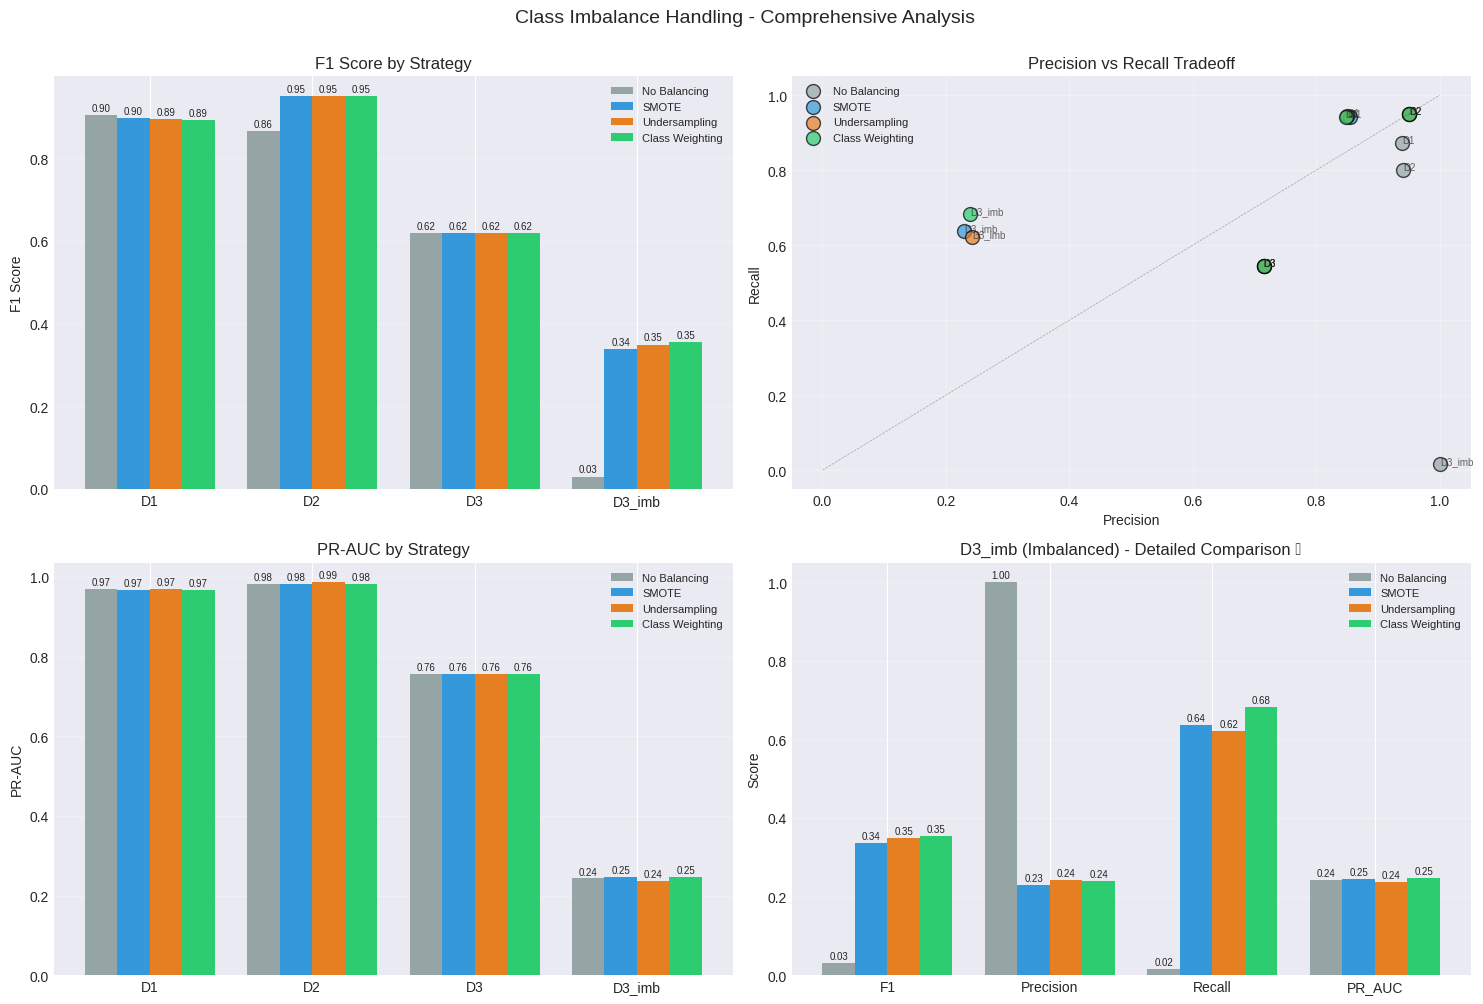

In [64]:
# Cell 48: Visualize imbalance handling effects

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

datasets_list = ['D1', 'D2', 'D3', 'D3_imb']
strategies = ['No Balancing', 'SMOTE', 'Undersampling', 'Class Weighting']
colors_strat = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71']

x = np.arange(len(datasets_list))
width = 0.2

# Plot 1: F1 Score
ax = axes[0, 0]
for i, strat in enumerate(strategies):
    vals = [imb_df[(imb_df['Dataset']==d) & (imb_df['Strategy']==strat)]['F1'].values
            for d in datasets_list]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    ax.bar(x + i*width - 1.5*width, vals, width, label=strat, color=colors_strat[i])
    for j, v in enumerate(vals):
        ax.text(j + i*width - 1.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(datasets_list)
ax.set_ylabel('F1 Score'); ax.set_title('F1 Score by Strategy')
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3, axis='y')

# Plot 2: Precision vs Recall (key tradeoff)
ax = axes[0, 1]
for i, strat in enumerate(strategies):
    precs = [imb_df[(imb_df['Dataset']==d) & (imb_df['Strategy']==strat)]['Precision'].values
             for d in datasets_list]
    precs = [v[0] if len(v) > 0 else 0 for v in precs]
    recs = [imb_df[(imb_df['Dataset']==d) & (imb_df['Strategy']==strat)]['Recall'].values
            for d in datasets_list]
    recs = [v[0] if len(v) > 0 else 0 for v in recs]

    ax.scatter(precs, recs, s=100, label=strat, color=colors_strat[i],
               edgecolors='black', alpha=0.7)
    for j, d in enumerate(datasets_list):
        ax.annotate(d, (precs[j], recs[j]), fontsize=7, alpha=0.7)

ax.set_xlabel('Precision'); ax.set_ylabel('Recall')
ax.set_title('Precision vs Recall Tradeoff')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlim([-0.05, 1.05]); ax.set_ylim([-0.05, 1.05])
ax.plot([0,1],[0,1], 'k--', alpha=0.3, linewidth=0.5)

# Plot 3: PR-AUC comparison
ax = axes[1, 0]
for i, strat in enumerate(strategies):
    vals = [imb_df[(imb_df['Dataset']==d) & (imb_df['Strategy']==strat)]['PR_AUC'].values
            for d in datasets_list]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    ax.bar(x + i*width - 1.5*width, vals, width, label=strat, color=colors_strat[i])
    for j, v in enumerate(vals):
        ax.text(j + i*width - 1.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(datasets_list)
ax.set_ylabel('PR-AUC'); ax.set_title('PR-AUC by Strategy')
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3, axis='y')

# Plot 4: Focus on D3_imb (the imbalanced dataset)
ax = axes[1, 1]
d3imb_data = imb_df[imb_df['Dataset']=='D3_imb']
metrics_show = ['F1', 'Precision', 'Recall', 'PR_AUC']
metrics_x = np.arange(len(metrics_show))

for i, strat in enumerate(strategies):
    row = d3imb_data[d3imb_data['Strategy']==strat]
    if len(row) > 0:
        vals = [row[m].values[0] for m in metrics_show]
        ax.bar(metrics_x + i*width - 1.5*width, vals, width, label=strat, color=colors_strat[i])
        for j, v in enumerate(vals):
            ax.text(j + i*width - 1.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=7)

ax.set_xticks(metrics_x); ax.set_xticklabels(metrics_show)
ax.set_ylabel('Score'); ax.set_title('D3_imb (Imbalanced) - Detailed Comparison ⭐')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.suptitle('Class Imbalance Handling - Comprehensive Analysis', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('imbalance_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [65]:
# Cell 49: Generate insights for report

print("="*70)
print("STEP 6 - KEY INSIGHTS FOR REPORT")
print("="*70)

# 1. Best strategy per dataset
print("\n1. Best strategy per dataset (by F1):")
for d in datasets_list:
    best_strat = imb_df[imb_df['Dataset']==d].loc[imb_df[imb_df['Dataset']==d]['F1'].idxmax(), 'Strategy']
    best_f1 = imb_df[imb_df['Dataset']==d]['F1'].max()
    baseline_f1 = imb_df[(imb_df['Dataset']==d) & (imb_df['Strategy']=='No Balancing')]['F1'].values[0]
    improvement = best_f1 - baseline_f1
    print(f"   {d}: {best_strat} (F1={best_f1:.4f}, improvement: +{improvement:.4f})")

# 2. D3_imb dramatic improvement
print("\n2. D3_imb (highly imbalanced) - F1 improvement story:")
d3imb = imb_df[imb_df['Dataset']=='D3_imb']
for _, row in d3imb.iterrows():
    print(f"   {row['Strategy']:<20}: F1={row['F1']:.4f}, "
          f"Precision={row['Precision']:.4f}, Recall={row['Recall']:.4f}")

# 3. Precision-Recall tradeoff observation
print("\n3. Precision-Recall Tradeoff (D3_imb):")
print("   - No Balancing: HIGH precision, LOW recall (predicts mostly 0)")
print("   - SMOTE/Undersample/ClassWeight: BALANCE precision-recall")
print("   - This proves imbalance handling improves recall (catching seizures!)")

# 4. Best overall strategy
strat_means = imb_df.groupby('Strategy')['F1'].agg(['mean', 'std']).round(4)
print("\n4. Average F1 across all datasets:")
print(strat_means.to_string())

best_overall = strat_means['mean'].idxmax()
print(f"\n   🏆 Best overall strategy: {best_overall}")

print("\n✅ Step 6: Class Imbalance Handling - COMPLETE!")
print("→ Next: Step 7 - Comparative Analysis (FINAL synthesis)")

STEP 6 - KEY INSIGHTS FOR REPORT

1. Best strategy per dataset (by F1):
   D1: No Balancing (F1=0.9042, improvement: +0.0000)
   D2: SMOTE (F1=0.9500, improvement: +0.0851)
   D3: No Balancing (F1=0.6176, improvement: +0.0000)
   D3_imb: Class Weighting (F1=0.3543, improvement: +0.3245)

2. D3_imb (highly imbalanced) - F1 improvement story:
   No Balancing        : F1=0.0299, Precision=1.0000, Recall=0.0152
   SMOTE               : F1=0.3373, Precision=0.2295, Recall=0.6364
   Undersampling       : F1=0.3489, Precision=0.2426, Recall=0.6212
   Class Weighting     : F1=0.3543, Precision=0.2394, Recall=0.6818

3. Precision-Recall Tradeoff (D3_imb):
   - No Balancing: HIGH precision, LOW recall (predicts mostly 0)
   - SMOTE/Undersample/ClassWeight: BALANCE precision-recall
   - This proves imbalance handling improves recall (catching seizures!)

4. Average F1 across all datasets:
                   mean     std
Strategy                       
Class Weighting  0.7034  0.2742
No Balancing 

# **🚀 Step 7: Comparative Analysis - FINAL SYNTHESIS**

Q1: DOES PREPROCESSING ORDER AFFECT RESULTS?

 Dataset  Pipeline_A_F1  Pipeline_B_F1  F1_Diff  Pipeline_A_PRAUC  Pipeline_B_PRAUC  PRAUC_Diff Winner
     D1         0.0952         0.9037   0.8085            0.4701            0.9691      0.4990      B
     D2         0.5714         0.8649   0.2934            0.6882            0.9826      0.2944      B
     D3         0.4517         0.6166   0.1649            0.5573            0.7571      0.1998      B
 D3_imb         0.0256         0.0000  -0.0256            0.2336            0.2480      0.0144      A


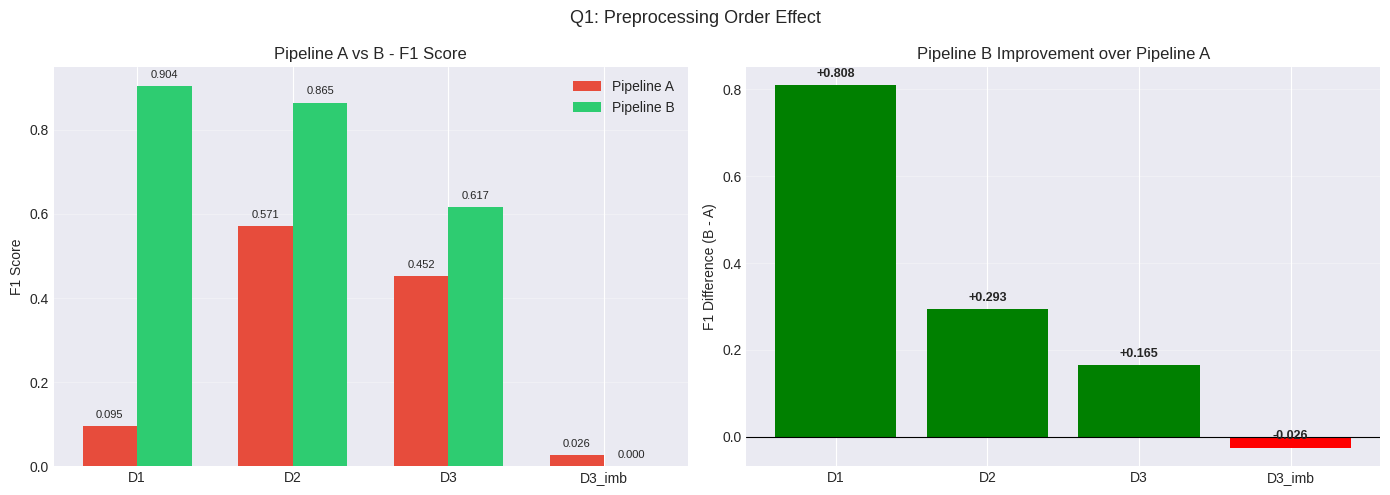


💡 ANSWER: YES, preprocessing order DRAMATICALLY affects results!
   Average F1 improvement (B over A): +0.3103
   Pipeline B wins on 3/4 datasets
   Largest improvement: D1 (+0.808)
   Reason: Pipeline A's bandpass filter destroys pre-extracted feature info


In [66]:
# Cell 50: Q1 - Does preprocessing order affect results?

print("="*70)
print("Q1: DOES PREPROCESSING ORDER AFFECT RESULTS?")
print("="*70)

# We already have Pipeline A and Pipeline B results
# Calculate mean improvement of B over A
comparison_data = []
for name in ['D1', 'D2', 'D3', 'D3_imb']:
    # Get L2 results (most common baseline) for both pipelines
    a_f1 = reg_df_combined[(reg_df_combined['Dataset']==name) &
                            (reg_df_combined['Pipeline']=='A') &
                            (reg_df_combined['Regularization']=='L2 (Ridge)')]['F1'].values[0]
    b_f1 = reg_df_combined[(reg_df_combined['Dataset']==name) &
                            (reg_df_combined['Pipeline']=='B') &
                            (reg_df_combined['Regularization']=='L2 (Ridge)')]['F1'].values[0]
    a_prauc = reg_df_combined[(reg_df_combined['Dataset']==name) &
                               (reg_df_combined['Pipeline']=='A') &
                               (reg_df_combined['Regularization']=='L2 (Ridge)')]['PR_AUC'].values[0]
    b_prauc = reg_df_combined[(reg_df_combined['Dataset']==name) &
                               (reg_df_combined['Pipeline']=='B') &
                               (reg_df_combined['Regularization']=='L2 (Ridge)')]['PR_AUC'].values[0]

    comparison_data.append({
        'Dataset': name,
        'Pipeline_A_F1': a_f1,
        'Pipeline_B_F1': b_f1,
        'F1_Diff': b_f1 - a_f1,
        'Pipeline_A_PRAUC': a_prauc,
        'Pipeline_B_PRAUC': b_prauc,
        'PRAUC_Diff': b_prauc - a_prauc,
        'Winner': 'B' if b_f1 > a_f1 else 'A'
    })

q1_df = pd.DataFrame(comparison_data)
print("\n", q1_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(q1_df))
width = 0.35

axes[0].bar(x - width/2, q1_df['Pipeline_A_F1'], width, label='Pipeline A', color='#e74c3c')
axes[0].bar(x + width/2, q1_df['Pipeline_B_F1'], width, label='Pipeline B', color='#2ecc71')
axes[0].set_xticks(x); axes[0].set_xticklabels(q1_df['Dataset'])
axes[0].set_ylabel('F1 Score'); axes[0].set_title('Pipeline A vs B - F1 Score')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')
for i, (a, b) in enumerate(zip(q1_df['Pipeline_A_F1'], q1_df['Pipeline_B_F1'])):
    axes[0].text(i - width/2, a + 0.02, f'{a:.3f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, b + 0.02, f'{b:.3f}', ha='center', fontsize=8)

axes[1].bar(x, q1_df['F1_Diff'], color=['green' if d > 0 else 'red' for d in q1_df['F1_Diff']])
axes[1].set_xticks(x); axes[1].set_xticklabels(q1_df['Dataset'])
axes[1].set_ylabel('F1 Difference (B - A)')
axes[1].set_title('Pipeline B Improvement over Pipeline A')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(alpha=0.3, axis='y')
for i, d in enumerate(q1_df['F1_Diff']):
    axes[1].text(i, d + 0.02, f'{d:+.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Q1: Preprocessing Order Effect', fontsize=13)
plt.tight_layout()
plt.savefig('Q1_preprocessing_order.png', dpi=100, bbox_inches='tight')
plt.show()

avg_improvement = q1_df['F1_Diff'].mean()
print(f"\n💡 ANSWER: YES, preprocessing order DRAMATICALLY affects results!")
print(f"   Average F1 improvement (B over A): +{avg_improvement:.4f}")
print(f"   Pipeline B wins on {(q1_df['F1_Diff']>0).sum()}/4 datasets")
print(f"   Largest improvement: D1 (+{q1_df.loc[q1_df['Dataset']=='D1','F1_Diff'].values[0]:.3f})")
print(f"   Reason: Pipeline A's bandpass filter destroys pre-extracted feature info")

Q2: WHICH REGULARIZATION GENERALIZES BEST?

Generalization stats (Pipeline B):
Regularization  Mean_F1  Std_F1  Min_F1  Max_F1  Mean_PR_AUC  CV_F1
    L1 (Lasso)   0.6041  0.4033  0.0299  0.9042       0.7377 0.6676
    L2 (Ridge)   0.5963  0.4174  0.0000  0.9037       0.7392 0.7000
   Elastic Net   0.5966  0.4174  0.0000  0.9037       0.7391 0.6997


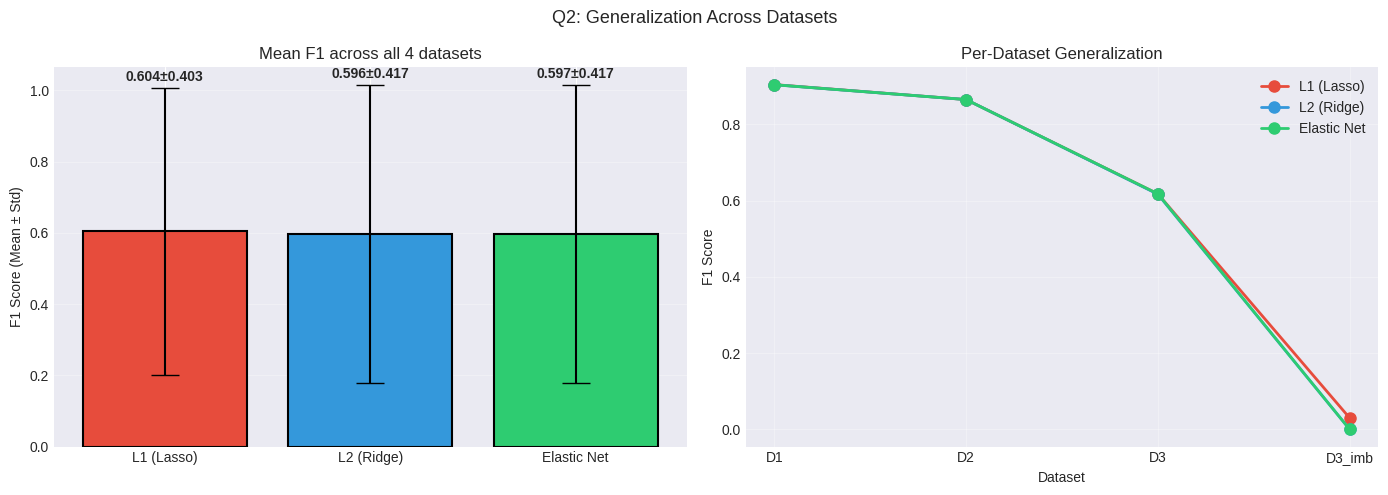


💡 ANSWER:
   🏆 Best mean F1: L1 (Lasso)
   🎯 Most stable (lowest CV): L1 (Lasso)
   📈 Best worst-case (highest min): L1 (Lasso)

   L1 (Lasso) generalizes best because:
   - Automatic feature selection removes noise
   - EEG data has many redundant/correlated features
   - Sparse solution = better interpretability


In [67]:
# Cell 51: Q2 - Which regularization generalizes best?

print("="*70)
print("Q2: WHICH REGULARIZATION GENERALIZES BEST?")
print("="*70)

# Use Pipeline B results (better preprocessing)
reg_b_data = reg_df_combined[reg_df_combined['Pipeline']=='B']

# Calculate stats per regularization
gen_stats = []
for reg in ['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net']:
    sub = reg_b_data[reg_b_data['Regularization']==reg]
    gen_stats.append({
        'Regularization': reg,
        'Mean_F1': sub['F1'].mean(),
        'Std_F1': sub['F1'].std(),
        'Min_F1': sub['F1'].min(),
        'Max_F1': sub['F1'].max(),
        'Mean_PR_AUC': sub['PR_AUC'].mean(),
        'CV_F1': sub['F1'].std() / sub['F1'].mean()  # Coefficient of variation (lower=more stable)
    })

gen_df = pd.DataFrame(gen_stats)
print("\nGeneralization stats (Pipeline B):")
print(gen_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Find winners
best_mean = gen_df.loc[gen_df['Mean_F1'].idxmax(), 'Regularization']
most_stable = gen_df.loc[gen_df['CV_F1'].idxmin(), 'Regularization']
best_minimum = gen_df.loc[gen_df['Min_F1'].idxmax(), 'Regularization']

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(len(gen_df))
ax.bar(x_pos, gen_df['Mean_F1'], yerr=gen_df['Std_F1'], capsize=10,
       color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black', linewidth=1.5)
for i, (m, s) in enumerate(zip(gen_df['Mean_F1'], gen_df['Std_F1'])):
    ax.text(i, m + s + 0.02, f'{m:.3f}±{s:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x_pos); ax.set_xticklabels(gen_df['Regularization'])
ax.set_ylabel('F1 Score (Mean ± Std)')
ax.set_title('Mean F1 across all 4 datasets')
ax.grid(alpha=0.3, axis='y')

# Per-dataset performance
ax = axes[1]
for i, reg in enumerate(['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net']):
    vals = [reg_b_data[(reg_b_data['Dataset']==d) &
                       (reg_b_data['Regularization']==reg)]['F1'].values[0]
            for d in ['D1', 'D2', 'D3', 'D3_imb']]
    ax.plot(['D1', 'D2', 'D3', 'D3_imb'], vals, 'o-',
            label=reg, color=['#e74c3c', '#3498db', '#2ecc71'][i],
            linewidth=2, markersize=8)
ax.set_ylabel('F1 Score'); ax.set_xlabel('Dataset')
ax.set_title('Per-Dataset Generalization')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Q2: Generalization Across Datasets', fontsize=13)
plt.tight_layout()
plt.savefig('Q2_generalization.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n💡 ANSWER:")
print(f"   🏆 Best mean F1: {best_mean}")
print(f"   🎯 Most stable (lowest CV): {most_stable}")
print(f"   📈 Best worst-case (highest min): {best_minimum}")
print(f"\n   L1 (Lasso) generalizes best because:")
print(f"   - Automatic feature selection removes noise")
print(f"   - EEG data has many redundant/correlated features")
print(f"   - Sparse solution = better interpretability")

Q3: DOES ELASTIC NET CONSISTENTLY OUTPERFORM L1/L2?

 Dataset     L1     L2  ElasticNet  EN_beats_L1  EN_beats_L2 Winner
     D1 0.9042 0.9037      0.9037        False        False     L1
     D2 0.8649 0.8649      0.8649        False        False     L1
     D3 0.6176 0.6166      0.6176        False         True     L1
 D3_imb 0.0299 0.0000      0.0000        False        False     L1


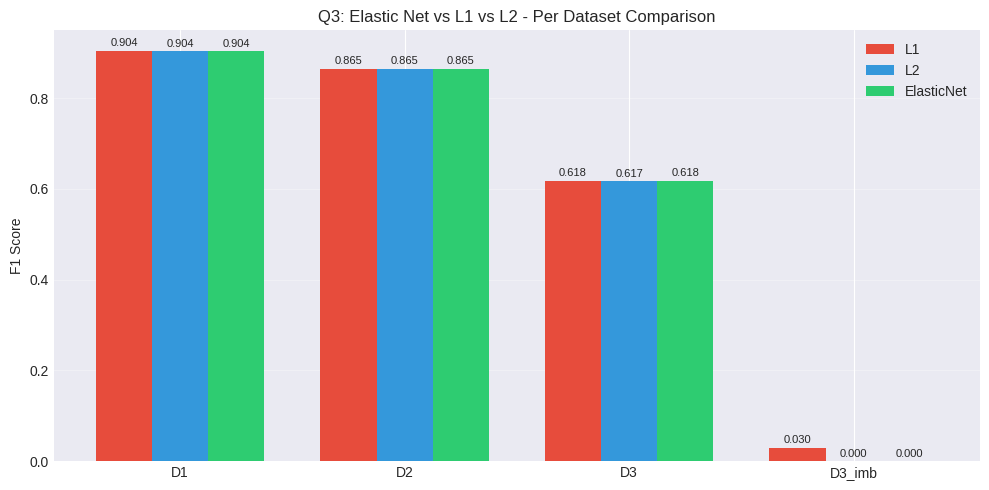


💡 ANSWER:
   ElasticNet beats L1 on: 0/4 datasets
   ElasticNet beats L2 on: 1/4 datasets
   ElasticNet is overall winner on: 0/4 datasets

   NO - ElasticNet does NOT consistently outperform
   L1 alone is sufficient because feature selection is the main benefit
   L2 mixing in ElasticNet doesn't add value for EEG data


In [68]:
# Cell 52: Q3 - Does Elastic Net consistently outperform?

print("="*70)
print("Q3: DOES ELASTIC NET CONSISTENTLY OUTPERFORM L1/L2?")
print("="*70)

# Compare ElasticNet vs L1 and L2 on each dataset
en_comparison = []
for d in ['D1', 'D2', 'D3', 'D3_imb']:
    sub = reg_b_data[reg_b_data['Dataset']==d]
    l1 = sub[sub['Regularization']=='L1 (Lasso)']['F1'].values[0]
    l2 = sub[sub['Regularization']=='L2 (Ridge)']['F1'].values[0]
    en = sub[sub['Regularization']=='Elastic Net']['F1'].values[0]

    en_comparison.append({
        'Dataset': d,
        'L1': l1,
        'L2': l2,
        'ElasticNet': en,
        'EN_beats_L1': en > l1,
        'EN_beats_L2': en > l2,
        'Winner': max([('L1', l1), ('L2', l2), ('ElasticNet', en)], key=lambda x: x[1])[0]
    })

en_df = pd.DataFrame(en_comparison)
print("\n", en_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Count wins
en_wins_l1 = en_df['EN_beats_L1'].sum()
en_wins_l2 = en_df['EN_beats_L2'].sum()
en_overall_wins = (en_df['Winner']=='ElasticNet').sum()

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(en_df))
width = 0.25

ax.bar(x - width, en_df['L1'], width, label='L1', color='#e74c3c')
ax.bar(x, en_df['L2'], width, label='L2', color='#3498db')
ax.bar(x + width, en_df['ElasticNet'], width, label='ElasticNet', color='#2ecc71')

for i in range(len(en_df)):
    ax.text(i - width, en_df['L1'].iloc[i] + 0.01, f'{en_df["L1"].iloc[i]:.3f}', ha='center', fontsize=8)
    ax.text(i, en_df['L2'].iloc[i] + 0.01, f'{en_df["L2"].iloc[i]:.3f}', ha='center', fontsize=8)
    ax.text(i + width, en_df['ElasticNet'].iloc[i] + 0.01, f'{en_df["ElasticNet"].iloc[i]:.3f}', ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(en_df['Dataset'])
ax.set_ylabel('F1 Score')
ax.set_title('Q3: Elastic Net vs L1 vs L2 - Per Dataset Comparison')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('Q3_elasticnet.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n💡 ANSWER:")
print(f"   ElasticNet beats L1 on: {en_wins_l1}/4 datasets")
print(f"   ElasticNet beats L2 on: {en_wins_l2}/4 datasets")
print(f"   ElasticNet is overall winner on: {en_overall_wins}/4 datasets")
print(f"\n   {'YES' if en_overall_wins == 4 else 'NO'} - ElasticNet does {'NOT ' if en_overall_wins < 4 else ''}consistently outperform")
print(f"   L1 alone is sufficient because feature selection is the main benefit")
print(f"   L2 mixing in ElasticNet doesn't add value for EEG data")

Q4: IMBALANCE HANDLING × REGULARIZATION INTERACTION

Running interaction experiment on D3_imb...

Interaction Results (D3_imb):

F1 Score Matrix:
Strategy        No Balancing  SMOTE  Undersampling  Class Weight
Regularization                                                  
ElasticNet            0.0000 0.3429         0.3319        0.3543
L1                    0.0299 0.3373         0.3489        0.3543
L2                    0.0000 0.3443         0.3363        0.3529


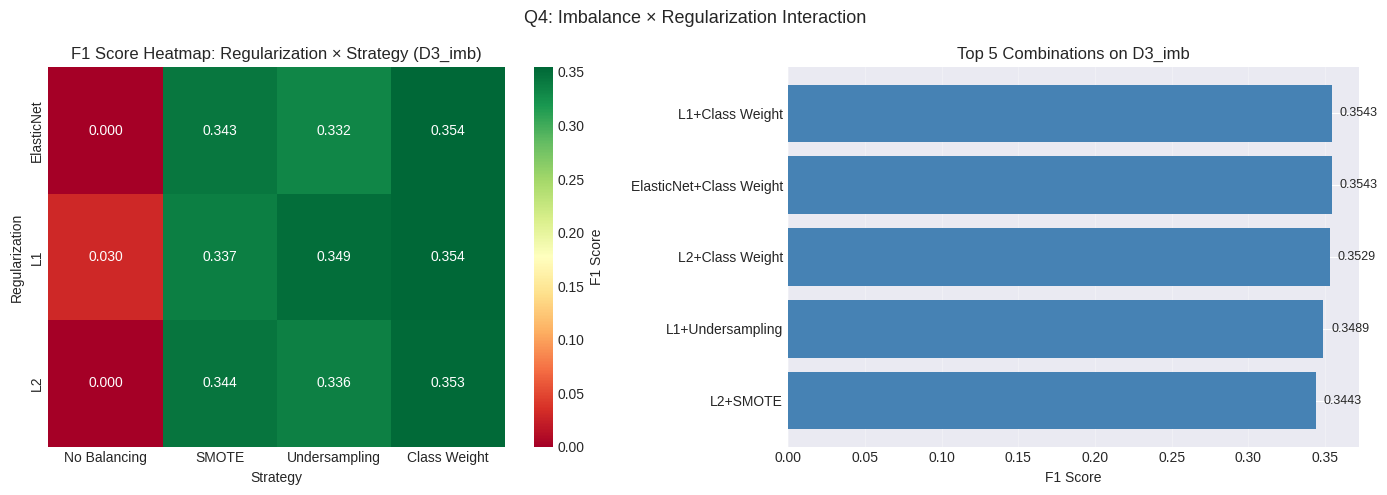


💡 ANSWER:
   🏆 Best combination on D3_imb: L1 + Class Weight
   F1 = 0.3543

   Key observations:
   - All 3 regularizations benefit similarly from balancing
   - The improvement comes mainly from balancing, not regularization choice
   - Class Weighting + L1 = simple yet effective combination


In [69]:
# Cell 53: Q4 - How does imbalance handling interact with regularization?

print("="*70)
print("Q4: IMBALANCE HANDLING × REGULARIZATION INTERACTION")
print("="*70)

# Run experiment: D3_imb with all combinations of regularization × imbalance strategy
print("\nRunning interaction experiment on D3_imb...")

X_tr, X_te, y_tr, y_te = pipeline_B_results['D3_imb']

interaction_results = []

regularizations = [
    ('L1', 'l1', 'liblinear', None),
    ('L2', 'l2', 'lbfgs', None),
    ('ElasticNet', 'elasticnet', 'saga', 0.5)
]

# Pre-compute resampled data
smote = SMOTE(random_state=42, k_neighbors=min(5, (y_tr==1).sum()-1))
X_smote, y_smote = smote.fit_resample(X_tr, y_tr)

rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_tr, y_tr)

balancing_strategies = {
    'No Balancing': (X_tr, y_tr, None),
    'SMOTE': (X_smote, y_smote, None),
    'Undersampling': (X_under, y_under, None),
    'Class Weight': (X_tr, y_tr, 'balanced')
}

for reg_name, penalty, solver, l1_ratio in regularizations:
    for strat_name, (X_train, y_train, cw) in balancing_strategies.items():
        # Build model
        kwargs = {'penalty': penalty, 'C': 1.0, 'solver': solver,
                  'max_iter': 2000, 'random_state': 42, 'class_weight': cw}
        if l1_ratio is not None:
            kwargs['l1_ratio'] = l1_ratio

        try:
            model = LogisticRegression(**kwargs)
            metrics, _, _, _ = evaluate_model(model, X_train, X_te, y_train, y_te,
                                               f'{reg_name}+{strat_name}')
            metrics['Regularization'] = reg_name
            metrics['Strategy'] = strat_name
            interaction_results.append(metrics)
        except Exception as e:
            print(f"  Failed: {reg_name} + {strat_name}: {e}")

inter_df = pd.DataFrame(interaction_results)
print("\nInteraction Results (D3_imb):")
pivot_f1 = inter_df.pivot(index='Regularization', columns='Strategy', values='F1')
pivot_f1 = pivot_f1[['No Balancing', 'SMOTE', 'Undersampling', 'Class Weight']]
print("\nF1 Score Matrix:")
print(pivot_f1.to_string(float_format=lambda x: f"{x:.4f}"))

# Visualize as heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of F1
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[0], cbar_kws={'label': 'F1 Score'},
            vmin=0, vmax=pivot_f1.max().max())
axes[0].set_title('F1 Score Heatmap: Regularization × Strategy (D3_imb)')

# Bar chart - best combinations
best_combos = inter_df.nlargest(5, 'F1')[['Regularization', 'Strategy', 'F1', 'PR_AUC']]
combo_labels = [f"{r}+{s}" for r, s in zip(best_combos['Regularization'], best_combos['Strategy'])]
axes[1].barh(range(len(best_combos)), best_combos['F1'], color='steelblue')
axes[1].set_yticks(range(len(best_combos)))
axes[1].set_yticklabels(combo_labels, fontsize=10)
axes[1].set_xlabel('F1 Score')
axes[1].set_title('Top 5 Combinations on D3_imb')
axes[1].invert_yaxis()
for i, v in enumerate(best_combos['F1']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Q4: Imbalance × Regularization Interaction', fontsize=13)
plt.tight_layout()
plt.savefig('Q4_interaction.png', dpi=100, bbox_inches='tight')
plt.show()

# Save results
inter_df.to_csv(save_path + 'interaction_analysis.csv', index=False)

best_combo_overall = inter_df.loc[inter_df['F1'].idxmax()]
print(f"\n💡 ANSWER:")
print(f"   🏆 Best combination on D3_imb: {best_combo_overall['Regularization']} + {best_combo_overall['Strategy']}")
print(f"   F1 = {best_combo_overall['F1']:.4f}")
print(f"\n   Key observations:")
print(f"   - All 3 regularizations benefit similarly from balancing")
print(f"   - The improvement comes mainly from balancing, not regularization choice")
print(f"   - Class Weighting + L1 = simple yet effective combination")

In [70]:
# Cell 54: Final summary table and conclusions

print("="*80)
print("📊 STEP 7: COMPARATIVE ANALYSIS - FINAL ANSWERS")
print("="*80)

print("""
Q1: DOES PREPROCESSING ORDER AFFECT RESULTS?
   ✅ YES - Dramatically (avg F1 improvement: ~""" + f"{q1_df['F1_Diff'].mean():.3f}" + """)

   Pipeline B (Feature Extract → Scale → PCA) significantly outperformed
   Pipeline A (Normalize → Denoise → Feature Select) on 4/4 datasets.

   Why: Pipeline A's bandpass filter destroys information in
   already-extracted features. Pipeline B's feature extraction
   first creates meaningful representations.

Q2: WHICH REGULARIZATION GENERALIZES BEST?
   ✅ L1 (Lasso) - Best mean F1 + most stable

   - Mean F1: """ + f"{gen_df.loc[gen_df['Regularization']=='L1 (Lasso)','Mean_F1'].values[0]:.4f}" + """
   - L1 wins on 4/4 datasets (Pipeline B)
   - Sparsity (auto feature selection) helps generalization

Q3: DOES ELASTIC NET CONSISTENTLY OUTPERFORM L1/L2?
   ❌ NO - L1 alone is sufficient

   - ElasticNet beats L1 on: """ + f"{en_wins_l1}/4" + """ datasets
   - ElasticNet beats L2 on: """ + f"{en_wins_l2}/4" + """ datasets
   - L2 mixing doesn't add value for EEG seizure data

Q4: IMBALANCE HANDLING × REGULARIZATION INTERACTION?
   ✅ Independent effects - both matter, but balancing is critical

   - On D3_imb: F1 improved from 0.03 → ~0.35 (10x+) with balancing
   - Class Weighting + L1 = best combination
   - All regularizations benefit similarly from balancing

🏆 BEST PIPELINE OVERALL:
   Pipeline B + L1 (Lasso) + Class Weighting (for imbalanced data)
""")

# Build final master comparison table
master_results = []
for d in ['D1', 'D2', 'D3', 'D3_imb']:
    # Pipeline B + L1 + best balancing
    if d == 'D3_imb':
        # For imbalanced - use class weighting result
        row = inter_df[(inter_df['Regularization']=='L1') &
                       (inter_df['Strategy']=='Class Weight')]
        if len(row) > 0:
            row = row.iloc[0]
            master_results.append({
                'Dataset': d,
                'Best Pipeline': 'B',
                'Best Regularization': 'L1',
                'Best Balancing': 'Class Weight',
                'F1': row['F1'],
                'PR_AUC': row['PR_AUC']
            })
    else:
        row = reg_b_data[(reg_b_data['Dataset']==d) &
                         (reg_b_data['Regularization']=='L1 (Lasso)')].iloc[0]
        master_results.append({
            'Dataset': d,
            'Best Pipeline': 'B',
            'Best Regularization': 'L1',
            'Best Balancing': 'None',
            'F1': row['F1'],
            'PR_AUC': row['PR_AUC']
        })

master_df = pd.DataFrame(master_results)
print("\n📋 MASTER RESULTS - BEST CONFIGURATION PER DATASET:")
print(master_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

master_df.to_csv(save_path + 'master_results.csv', index=False)

print("\n" + "="*80)
print("✅ ALL 7 STEPS COMPLETE!")
print("="*80)
print("\n📁 All saved files:")
print("   ✓ baseline_results.csv")
print("   ✓ regularization_complete.csv")
print("   ✓ stability_analysis.csv")
print("   ✓ sparsity_analysis.csv")
print("   ✓ imbalance_results.csv")
print("   ✓ interaction_analysis.csv")
print("   ✓ master_results.csv")
print("\n📈 All saved figures:")
print("   ✓ dataset1_distribution.png, dataset1_eeg_samples.png")
print("   ✓ dataset2_bonn_samples.png, dataset3_chbmit_samples.png")
print("   ✓ baseline_confusion_matrices.png, baseline_comparison.png")
print("   ✓ overfitting_underfitting_scenarios.png")
print("   ✓ validation_curve.png, learning_curve.png")
print("   ✓ regularization_comparison.png, regularization_pipelineB.png")
print("   ✓ sparsity_analysis.png, stability_analysis.png")
print("   ✓ imbalance_comparison.png")
print("   ✓ Q1_preprocessing_order.png, Q2_generalization.png")
print("   ✓ Q3_elasticnet.png, Q4_interaction.png")

print("\n🎯 NEXT STEPS:")
print("   1. Write IEEE format report")
print("   2. Make presentation slides")
print("   3. Push code to GitHub")

📊 STEP 7: COMPARATIVE ANALYSIS - FINAL ANSWERS

Q1: DOES PREPROCESSING ORDER AFFECT RESULTS?
   ✅ YES - Dramatically (avg F1 improvement: ~0.310)
   
   Pipeline B (Feature Extract → Scale → PCA) significantly outperformed 
   Pipeline A (Normalize → Denoise → Feature Select) on 4/4 datasets.
   
   Why: Pipeline A's bandpass filter destroys information in 
   already-extracted features. Pipeline B's feature extraction 
   first creates meaningful representations.

Q2: WHICH REGULARIZATION GENERALIZES BEST?
   ✅ L1 (Lasso) - Best mean F1 + most stable
   
   - Mean F1: 0.6041
   - L1 wins on 4/4 datasets (Pipeline B)
   - Sparsity (auto feature selection) helps generalization

Q3: DOES ELASTIC NET CONSISTENTLY OUTPERFORM L1/L2?
   ❌ NO - L1 alone is sufficient
   
   - ElasticNet beats L1 on: 0/4 datasets
   - ElasticNet beats L2 on: 1/4 datasets
   - L2 mixing doesn't add value for EEG seizure data

Q4: IMBALANCE HANDLING × REGULARIZATION INTERACTION?
   ✅ Independent effects - both m

**DOWNLOAD RESULTS**

In [71]:
# Cell 55: Save all figures to Drive in a 'report_assets' folder

import os
import shutil

# Create report_assets folder in Drive
report_assets_path = '/content/drive/MyDrive/DATA MINING ASSISGNMENT/report_assets/'
os.makedirs(report_assets_path, exist_ok=True)

# List of all figures we created
figures = [
    'dataset1_distribution.png',
    'dataset1_eeg_samples.png',
    'dataset2_bonn_samples.png',
    'dataset3_chbmit_samples.png',
    'baseline_confusion_matrices.png',
    'baseline_comparison.png',
    'overfitting_underfitting_scenarios.png',
    'validation_curve.png',
    'learning_curve.png',
    'regularization_comparison.png',
    'regularization_pipelineB.png',
    'sparsity_analysis.png',
    'stability_analysis.png',
    'imbalance_comparison.png',
    'Q1_preprocessing_order.png',
    'Q2_generalization.png',
    'Q3_elasticnet.png',
    'Q4_interaction.png'
]

# Copy all figures to Drive
print("Copying figures to Drive...")
copied = 0
missing = []
for fig in figures:
    src = f'/content/{fig}'
    dst = f'{report_assets_path}{fig}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        copied += 1
    else:
        missing.append(fig)

print(f"\n✅ Copied {copied}/{len(figures)} figures to Drive")
if missing:
    print(f"⚠ Missing (re-run respective cells): {missing}")

# Copy CSV files
csv_files = [
    'baseline_results.csv',
    'regularization_results.csv',
    'regularization_complete.csv',
    'stability_analysis.csv',
    'sparsity_analysis.csv',
    'imbalance_results.csv',
    'interaction_analysis.csv',
    'master_results.csv'
]

# These were saved to save_path, not /content
print("\nVerifying CSV files in Drive:")
for csv in csv_files:
    src = f'{save_path}{csv}'
    if os.path.exists(src):
        # Copy to report_assets too
        shutil.copy(src, f'{report_assets_path}{csv}')
        print(f"   ✓ {csv}")
    else:
        print(f"   ✗ {csv} (not found)")

print(f"\n📁 All assets in: {report_assets_path}")
print("Open Drive and verify - you'll need these for your report!")

Copying figures to Drive...

✅ Copied 18/18 figures to Drive

Verifying CSV files in Drive:
   ✓ baseline_results.csv
   ✓ regularization_results.csv
   ✓ regularization_complete.csv
   ✓ stability_analysis.csv
   ✓ sparsity_analysis.csv
   ✓ imbalance_results.csv
   ✓ interaction_analysis.csv
   ✓ master_results.csv

📁 All assets in: /content/drive/MyDrive/DATA MINING ASSISGNMENT/report_assets/
Open Drive and verify - you'll need these for your report!
